In [136]:
!pip install rdkit-pypi
!pip install scipy
!pip install py3Dmol


In [137]:
from rdkit import Chem
from rdkit.Chem import AllChem
import pandas as pd
import numpy as np

In [138]:
df = pd.read_csv("morgan_fingerprints_targets_progress.csv")
df = df.dropna(subset=['smiles'])
df = df[df['name']!= '[]']
df['smiles'] = df['smiles'].apply(lambda x: x[2:-2])


In [139]:
# Convert to RDKit molecules
mols = [Chem.MolFromSmiles(s) for s in df['smiles']]

# Compute Morgan fingerprints
fps = [AllChem.GetMorganFingerprintAsBitVect(m, radius=2, nBits=1024) for m in mols]

# Convert to numpy array (optional, for ML)
fps_array = np.array([np.frombuffer(fp.ToBitString().encode('utf-8'), 'u1') - ord('0') for fp in fps])
fps_array

[18:09:19] WARNING: not removing hydrogen atom without neighbors
[18:09:19] WARNING: not removing hydrogen atom without neighbors
[18:09:19] WARNING: not removing hydrogen atom without neighbors
[18:09:19] WARNING: not removing hydrogen atom without neighbors
[18:09:19] WARNING: not removing hydrogen atom without neighbors
[18:09:19] WARNING: not removing hydrogen atom without neighbors
[18:09:19] WARNING: not removing hydrogen atom without neighbors
[18:09:19] WARNING: not removing hydrogen atom without neighbors
[18:09:19] WARNING: not removing hydrogen atom without neighbors
[18:09:19] WARNING: not removing hydrogen atom without neighbors
[18:09:19] WARNING: not removing hydrogen atom without neighbors
[18:09:19] WARNING: not removing hydrogen atom without neighbors
[18:09:19] WARNING: not removing hydrogen atom without neighbors
[18:09:19] WARNING: not removing hydrogen atom without neighbors
[18:09:19] WARNING: not removing hydrogen atom without neighbors
[18:09:19] WARNING: not r

array([[0, 1, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [140]:
top_words = pd.read_csv('top_words_from_the_pearl.txt', delimiter='\t')
top_words

,word,frequency
0,the,2187
1,and,1599
2,of,612
3,a,610
4,he,597
...,...,...
1019,burning,3
1020,hide,3
1021,dried,3
1022,sandy,3


In [141]:
column_populations = fps_array.sum(axis=0)
sorted_column_indices = np.argsort(column_populations)[::-1]
sorted_column_indices

def row_to_words(row):
    """Get the top N words for a given row based on column population order"""
    # Get indices where this row has 1s
    active_columns = np.where(row == 1)[0]
    print(active_columns)
    # Map to words and sort by column population
    words_with_col= [(top_words.iloc[col]['word'], col) for col in active_columns]
    print(words_with_col)
    # words_with_pop.sort(key=lambda x: x[1], reverse=True)
    return words_with_col


In [142]:
FAMILY = 'American Typewriter'

def typewriter_molecule_art_v2(smiles, words_to_embed, 
                               letter_spacing=0.0085,
                               target_length=20,
                               spacing_char='',
                               font_size=21,
                               vertical_jitter=0.03,
                               letter_spacing_jitter=0.03,
                               dashed_line_multiplier_for_bonds=4.5,
                               aromatic_circle_offset= 0.1,
                               show_hydrogens=False,
                               radius=2,
                               reference_size = 15,
                               auto_scale = True):
    """
    Cleaner typewriter-style molecule with better spacing.
    Now includes aromatic ring "typed" circles.
    """
    from rdkit import Chem
    from rdkit.Chem import AllChem
    import matplotlib.pyplot as plt
    import numpy as np

    # Prepare molecule
    mol = Chem.MolFromSmiles(smiles)
    if not show_hydrogens:
        mol = Chem.RemoveHs(mol)
    else:
        mol = Chem.AddHs(mol)

    AllChem.Compute2DCoords(mol)

    fig, ax = plt.subplots(figsize=(20, 20), facecolor='white')
    conf = mol.GetConformer()


    xs = [conf.GetAtomPosition(i).x for i in range(mol.GetNumAtoms())]
    ys = [conf.GetAtomPosition(i).y for i in range(mol.GetNumAtoms())]
    mol_size = max(max(xs) - min(xs), max(ys) - min(ys), 1e-6)
    scale_factor = mol_size / reference_size if auto_scale else 1.0
    font_size = font_size / scale_factor
    print('scale_factor ', scale_factor , ' font_size ', font_size)

    # Get fingerprint info - ONLY radius 2
    info = {}
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=1024, bitInfo=info)

    # Map bits to words
    bit_to_word = {bit_idx: word for word, bit_idx in words_to_embed}

    # Assign words to bonds
    bond_words = {}
    for bit_idx, word in bit_to_word.items():
        if bit_idx in info:
            atom_idx, rad = info[bit_idx][0]
            env = Chem.FindAtomEnvironmentOfRadiusN(mol, rad, atom_idx)
            for bond_idx in env:
                if bond_idx not in bond_words:
                    bond_words[bond_idx] = word
                    break

    print(f"Mapped {len(bond_words)} words to {mol.GetNumBonds()} bonds")
    print(f"Bonds with words: {sorted(bond_words.keys())}")
    print(f"Bonds without words: {[b.GetIdx() for b in mol.GetBonds() if b.GetIdx() not in bond_words]}")

    # --- Helper Functions ---
    def format_word_for_bond(word, target_len, spacing_char):
        """Format word to target length with tighter spacing"""
        if spacing_char == '-' or spacing_char == '.':
            spaced = spacing_char.join(list(word))
            if len(spaced) < target_len:
                padding_needed = target_len - len(spaced)
                left_pad = padding_needed // 2
                right_pad = padding_needed - left_pad
                spaced = spacing_char * left_pad + spaced + spacing_char * right_pad
            return spaced[:target_len]
        elif spacing_char is None:
            repeated = (word * (target_len // len(word) + 1))[:target_len]
            return repeated
        else:
            spaced = spacing_char.join(list(word))
            if len(spaced) < target_len:
                padding_needed = target_len - len(spaced)
                left_pad = padding_needed // 2
                right_pad = padding_needed - left_pad
                spaced = spacing_char * left_pad + spaced + spacing_char * right_pad
            return spaced[:target_len]

    def draw_jittered_text(ax, text, x, y, angle, fontsize, jitter_y, jitter_x):
        """Draw text with subtle jitter - TIGHTER SPACING"""
        angle_rad = np.radians(angle)
        dx = np.cos(angle_rad)
        dy = np.sin(angle_rad)
        perp_dx = -np.sin(angle_rad)
        perp_dy = np.cos(angle_rad)
        char_width = fontsize * letter_spacing  # Reduced spacing
        text_len = len(text)
        start_offset = -(text_len * char_width) / 2

        for i, char in enumerate(text):
            h_offset = start_offset + i * char_width + np.random.uniform(-jitter_x, jitter_x)
            v_offset = np.random.uniform(-jitter_y, jitter_y)
            char_x = x + h_offset * dx + v_offset * perp_dx
            char_y = y + h_offset * dy + v_offset * perp_dy
            char_angle = angle + np.random.uniform(-1, 1)
            ax.text(char_x, char_y, char,
                    rotation=char_angle,
                    rotation_mode='anchor',
                    ha='center', va='center',
                    fontsize=fontsize,
                    weight='normal',
                    family=FAMILY,
                    color='black')

    # def draw_typewriter_circle(ax, center_x, center_y, radius, text='-', font_size=11,
    #                            vertical_jitter=0.02, letter_spacing_jitter=0.01, num_chars=100):
    #     """Draws a circular dashed line using typewriter aesthetic."""
    #     for i in range(num_chars):
    #         theta = 2 * np.pi * i / num_chars
    #         x = center_x + radius * np.cos(theta)
    #         y = center_y + radius * np.sin(theta)
    #         angle = np.degrees(theta + np.pi / 2)
    #         draw_jittered_text(ax, text, x, y, angle,
    #                            font_size, vertical_jitter, letter_spacing_jitter)
            
    def draw_typewriter_circle(ax, center_x, center_y, radius, text='-', font_size=11,
                           vertical_jitter=0.02, letter_spacing_jitter=0.01, num_chars=100):
        """Draws a circular dashed line using typewriter aesthetic, 
        with proper tangent alignment."""
        char_angle = 2 * np.pi / num_chars
        for i in range(num_chars):
            # Angle at the midpoint of the dash placement
            theta = char_angle * (i + 0.5 + aromatic_circle_offset)
            x = center_x + radius * np.cos(theta)
            y = center_y + radius * np.sin(theta)
            
            # Tangent angle — perpendicular to the radius
            angle = np.degrees(theta + np.pi / 2)

            # Draw each dash or word following the circular path
            draw_jittered_text(ax, text, x, y, angle,
                            font_size, vertical_jitter, letter_spacing_jitter)


    # --- Draw Bonds ---
    for bond in mol.GetBonds():
        bond_idx = bond.GetIdx()
        begin_idx = bond.GetBeginAtomIdx()
        end_idx = bond.GetEndAtomIdx()

        p1 = conf.GetAtomPosition(begin_idx)
        p2 = conf.GetAtomPosition(end_idx)
        bond_type = bond.GetBondType()
        is_double = (bond_type == Chem.BondType.DOUBLE)
        is_triple = (bond_type == Chem.BondType.TRIPLE)

        # Determine if bond is aromatic
        is_aromatic = bond.GetIsAromatic()

        if bond_idx in bond_words:
            word = bond_words[bond_idx]
            formatted_word = format_word_for_bond(word, target_length, spacing_char)
            angle = np.degrees(np.arctan2(p2.y - p1.y, p2.x - p1.x))
            if angle > 90 or angle < -90:
                angle += 180
            mid_x, mid_y = (p1.x + p2.x) / 2, (p1.y + p2.y) / 2
            if is_double:
                angle_rad = np.radians(angle)
                perp_dx = -np.sin(angle_rad) * 0.15
                perp_dy = np.cos(angle_rad) * 0.15
                draw_jittered_text(ax, formatted_word, mid_x + perp_dx, mid_y + perp_dy, angle,
                                   font_size, vertical_jitter, letter_spacing_jitter)
                draw_jittered_text(ax, formatted_word, mid_x - perp_dx, mid_y - perp_dy, angle,
                                   font_size, vertical_jitter, letter_spacing_jitter)
            elif is_triple:
                angle_rad = np.radians(angle)
                perp_dx = -np.sin(angle_rad) * 0.15
                perp_dy = np.cos(angle_rad) * 0.15
                draw_jittered_text(ax, formatted_word, mid_x + perp_dx, mid_y + perp_dy, angle,
                                   font_size, vertical_jitter, letter_spacing_jitter)
                draw_jittered_text(ax, formatted_word, mid_x, mid_y, angle,
                                   font_size, vertical_jitter, letter_spacing_jitter)
                draw_jittered_text(ax, formatted_word, mid_x - perp_dx, mid_y - perp_dy, angle,
                                   font_size, vertical_jitter, letter_spacing_jitter)
            else:
                draw_jittered_text(ax, formatted_word, mid_x, mid_y, angle,
                                   font_size, vertical_jitter, letter_spacing_jitter)
        else:
            # Draw as dashed line (typewriter style)
            bond_length = np.sqrt((p2.x - p1.x)**2 + (p2.y - p1.y)**2)
            num_dashes = int(bond_length * dashed_line_multiplier_for_bonds)
            dash_text = '-' * num_dashes
            angle = np.degrees(np.arctan2(p2.y - p1.y, p2.x - p1.x))
            if angle > 90 or angle < -90:
                angle += 180
            mid_x, mid_y = (p1.x + p2.x) / 2, (p1.y + p2.y) / 2
            if is_double or is_triple:
                angle_rad = np.radians(angle)
                perp_dx = -np.sin(angle_rad) * 0.4
                perp_dy = np.cos(angle_rad) * 0.4
                offsets = [-0.15, 0, 0.15] if is_triple else [-0.15, 0.15]
                for off in offsets:
                    draw_jittered_text(ax, dash_text, mid_x + off * perp_dx, mid_y + off * perp_dy, angle,
                                       font_size * 1.4, vertical_jitter, letter_spacing_jitter)
            else:
                draw_jittered_text(ax, dash_text , mid_x, mid_y, angle,
                                   font_size * 1.4, vertical_jitter, letter_spacing_jitter)

    # --- Draw aromatic ring circles ---
    ring_info = mol.GetRingInfo()
    aromatic_rings = [ring for ring in ring_info.AtomRings()
                      if all(mol.GetAtomWithIdx(i).GetIsAromatic() for i in ring)]

    for ring in aromatic_rings:
        coords = np.array([[conf.GetAtomPosition(i).x, conf.GetAtomPosition(i).y] for i in ring])
        centroid = coords.mean(axis=0)
        radius_ring = np.mean(np.sqrt(np.sum((coords - centroid)**2, axis=1)))
        inner_radius = radius_ring * 0.7

        draw_typewriter_circle(ax, centroid[0], centroid[1], inner_radius,
                               text='-', font_size=font_size * 1.4,
                               vertical_jitter=vertical_jitter,
                               letter_spacing_jitter=letter_spacing_jitter,
                               num_chars=30)

    # --- Draw atoms ---
    for i in range(mol.GetNumAtoms()):
        atom = mol.GetAtomWithIdx(i)
        if not show_hydrogens and atom.GetSymbol() == 'H':
            continue
        pos = conf.GetAtomPosition(i)
        ax.plot(pos.x, pos.y, 'o',
                markersize=0,
                color='black',
                markerfacecolor='white',
                markeredgewidth=2.5,
                zorder=2)

    ax.axis('equal')
    ax.axis('off')
    ax.margins(0.12)
    plt.tight_layout()
    return fig, bond_words


## BIG MEDIUM


[   1    5   18   33   36  125  126  128  130  147  181  233  250  251
  255  274  289  314  341  356  362  387  389  407  573  578  585  607
  611  650  673  675  697  709  726  745  753  754  786  807  829  849
  893  913  919  935 1019]
[('and', 1), ('his', 5), ('had', 18), ('eyes', 33), ('you', 36), ('family', 125), ('fire', 126), ('black', 128), ('door', 130), ('watched', 147), ('air', 181), ('blanket', 233), ('dealer', 250), ('still', 251), ('slipped', 255), ('secret', 274), ('almost', 289), ('cave', 314), ('price', 341), ('followed', 356), ('many', 362), ('nose', 387), ('waves', 389), ('warm', 407), ('together', 573), ('yes', 578), ('disappeared', 585), ('school', 607), ('desert', 611), ('arranged', 650), ('death', 673), ('boy', 675), ('silver', 697), ('paper', 709), ('continued', 726), ('below', 745), ('faces', 753), ('whisper', 754), ('fool', 786), ('pools', 807), ('pile', 829), ('laughed', 849), ('although', 893), ('thrown', 913), ('next', 919), ('really', 935), ('burning', 1

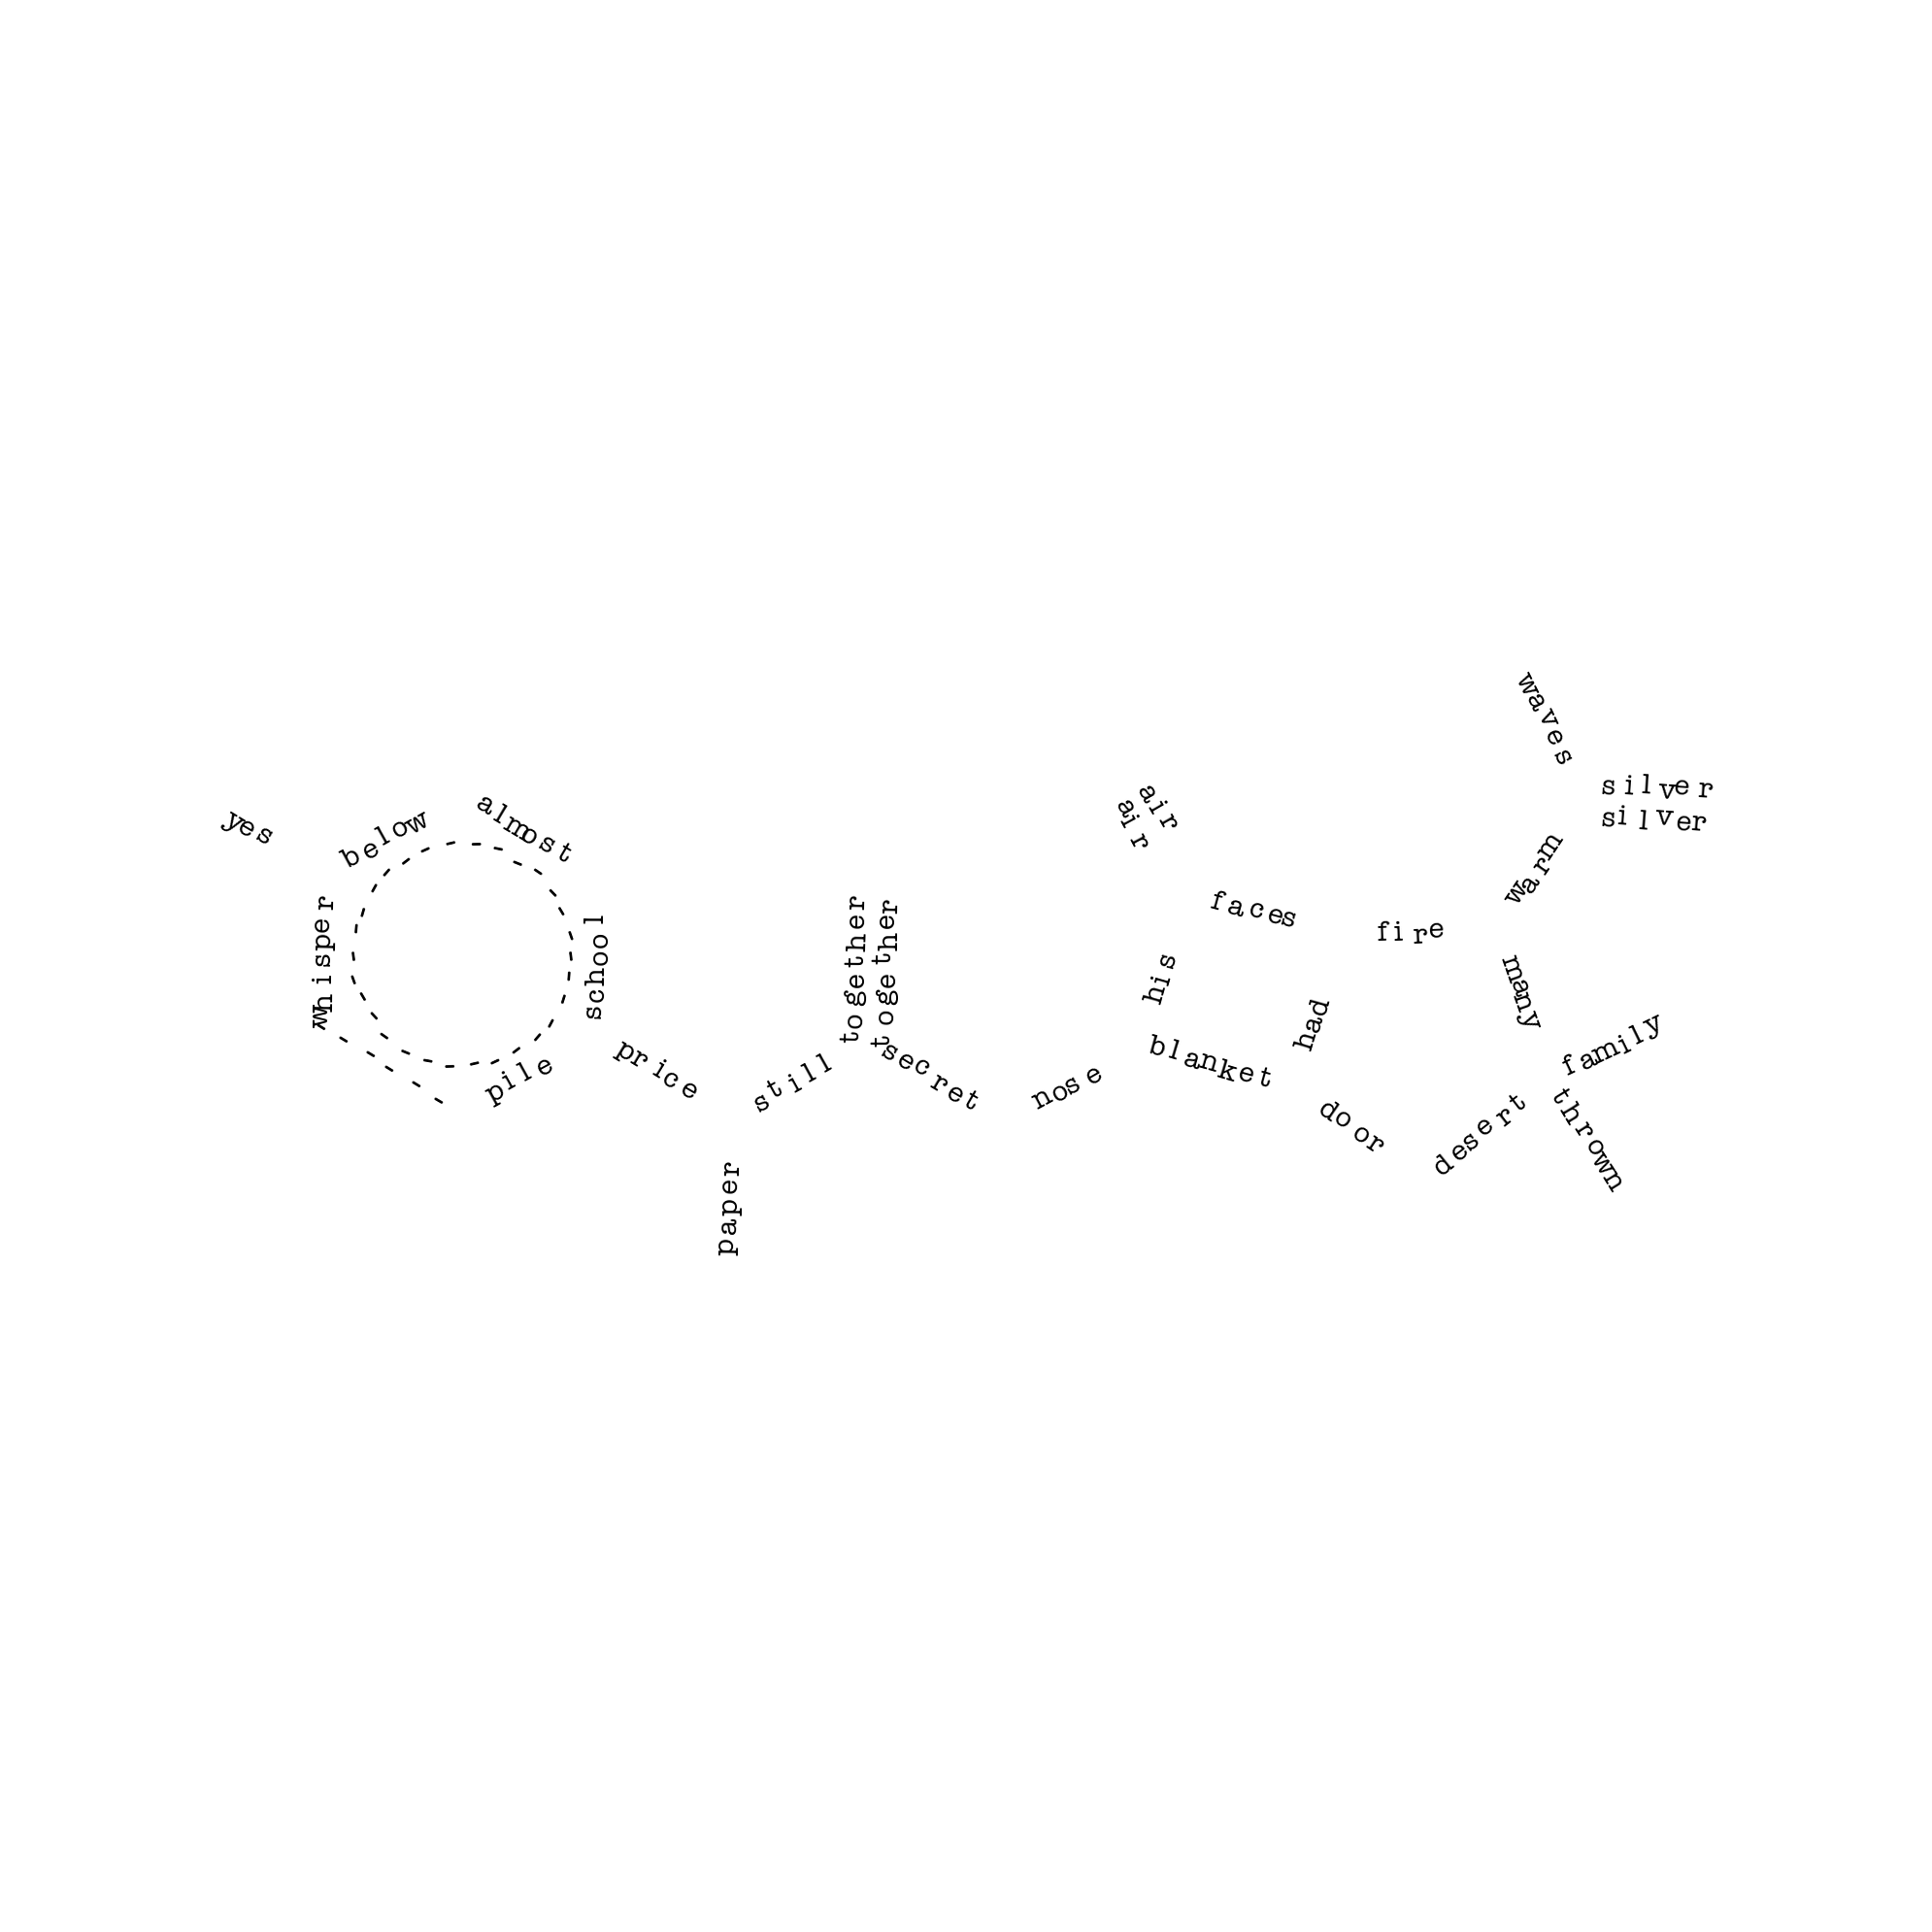

In [143]:
index = 0
# print(df.iloc[index]['smiles'])
# hybrid_word_bond_molecule(df.iloc[index]['smiles'], row_to_words(fps_array[index]))

# 1. With dashes (classic typewriter)
fig, mapping = typewriter_molecule_art_v2(
    smiles=df.iloc[index]['smiles'],
    words_to_embed=row_to_words(fps_array[index]),
    target_length=20,
    spacing_char='',
    font_size=21,
    vertical_jitter=0.03,
    letter_spacing_jitter=0.03
)
# plt.savefig('typewriter_dashes.png', dpi=300, bbox_inches='tight', facecolor='white')



[   1   20   33   46   80  102  117  118  119  128  171  203  210  222
  227  233  243  259  278  292  294  299  332  362  371  375  401  416
  420  463  473  492  522  539  540  550  573  576  591  600  610  646
  650  656  682  687  693  694  695  731  739  740  775  794  807  820
  823  849  887  890  893  897  923  926  953  967 1019]
[('and', 1), ('she', 20), ('eyes', 33), ('be', 46), ('people', 80), ('music', 102), ('thing', 117), ('us', 118), ('some', 119), ('black', 128), ('soft', 171), ('own', 203), ('afraid', 210), ('walked', 222), ('moon', 227), ('blanket', 233), ('than', 243), ('enemy', 259), ('set', 278), ('each', 292), ('nearly', 294), ('legs', 299), ('money', 332), ('many', 362), ('sell', 371), ('doorway', 375), ('close', 401), ('animals', 416), ('canoes', 420), ('estuary', 463), ('picked', 473), ('everything', 492), ('knuckles', 522), ('settled', 539), ('clean', 540), ('half', 550), ('together', 573), ('thumb', 576), ('destroyed', 591), ('washed', 600), ('thou', 610), (

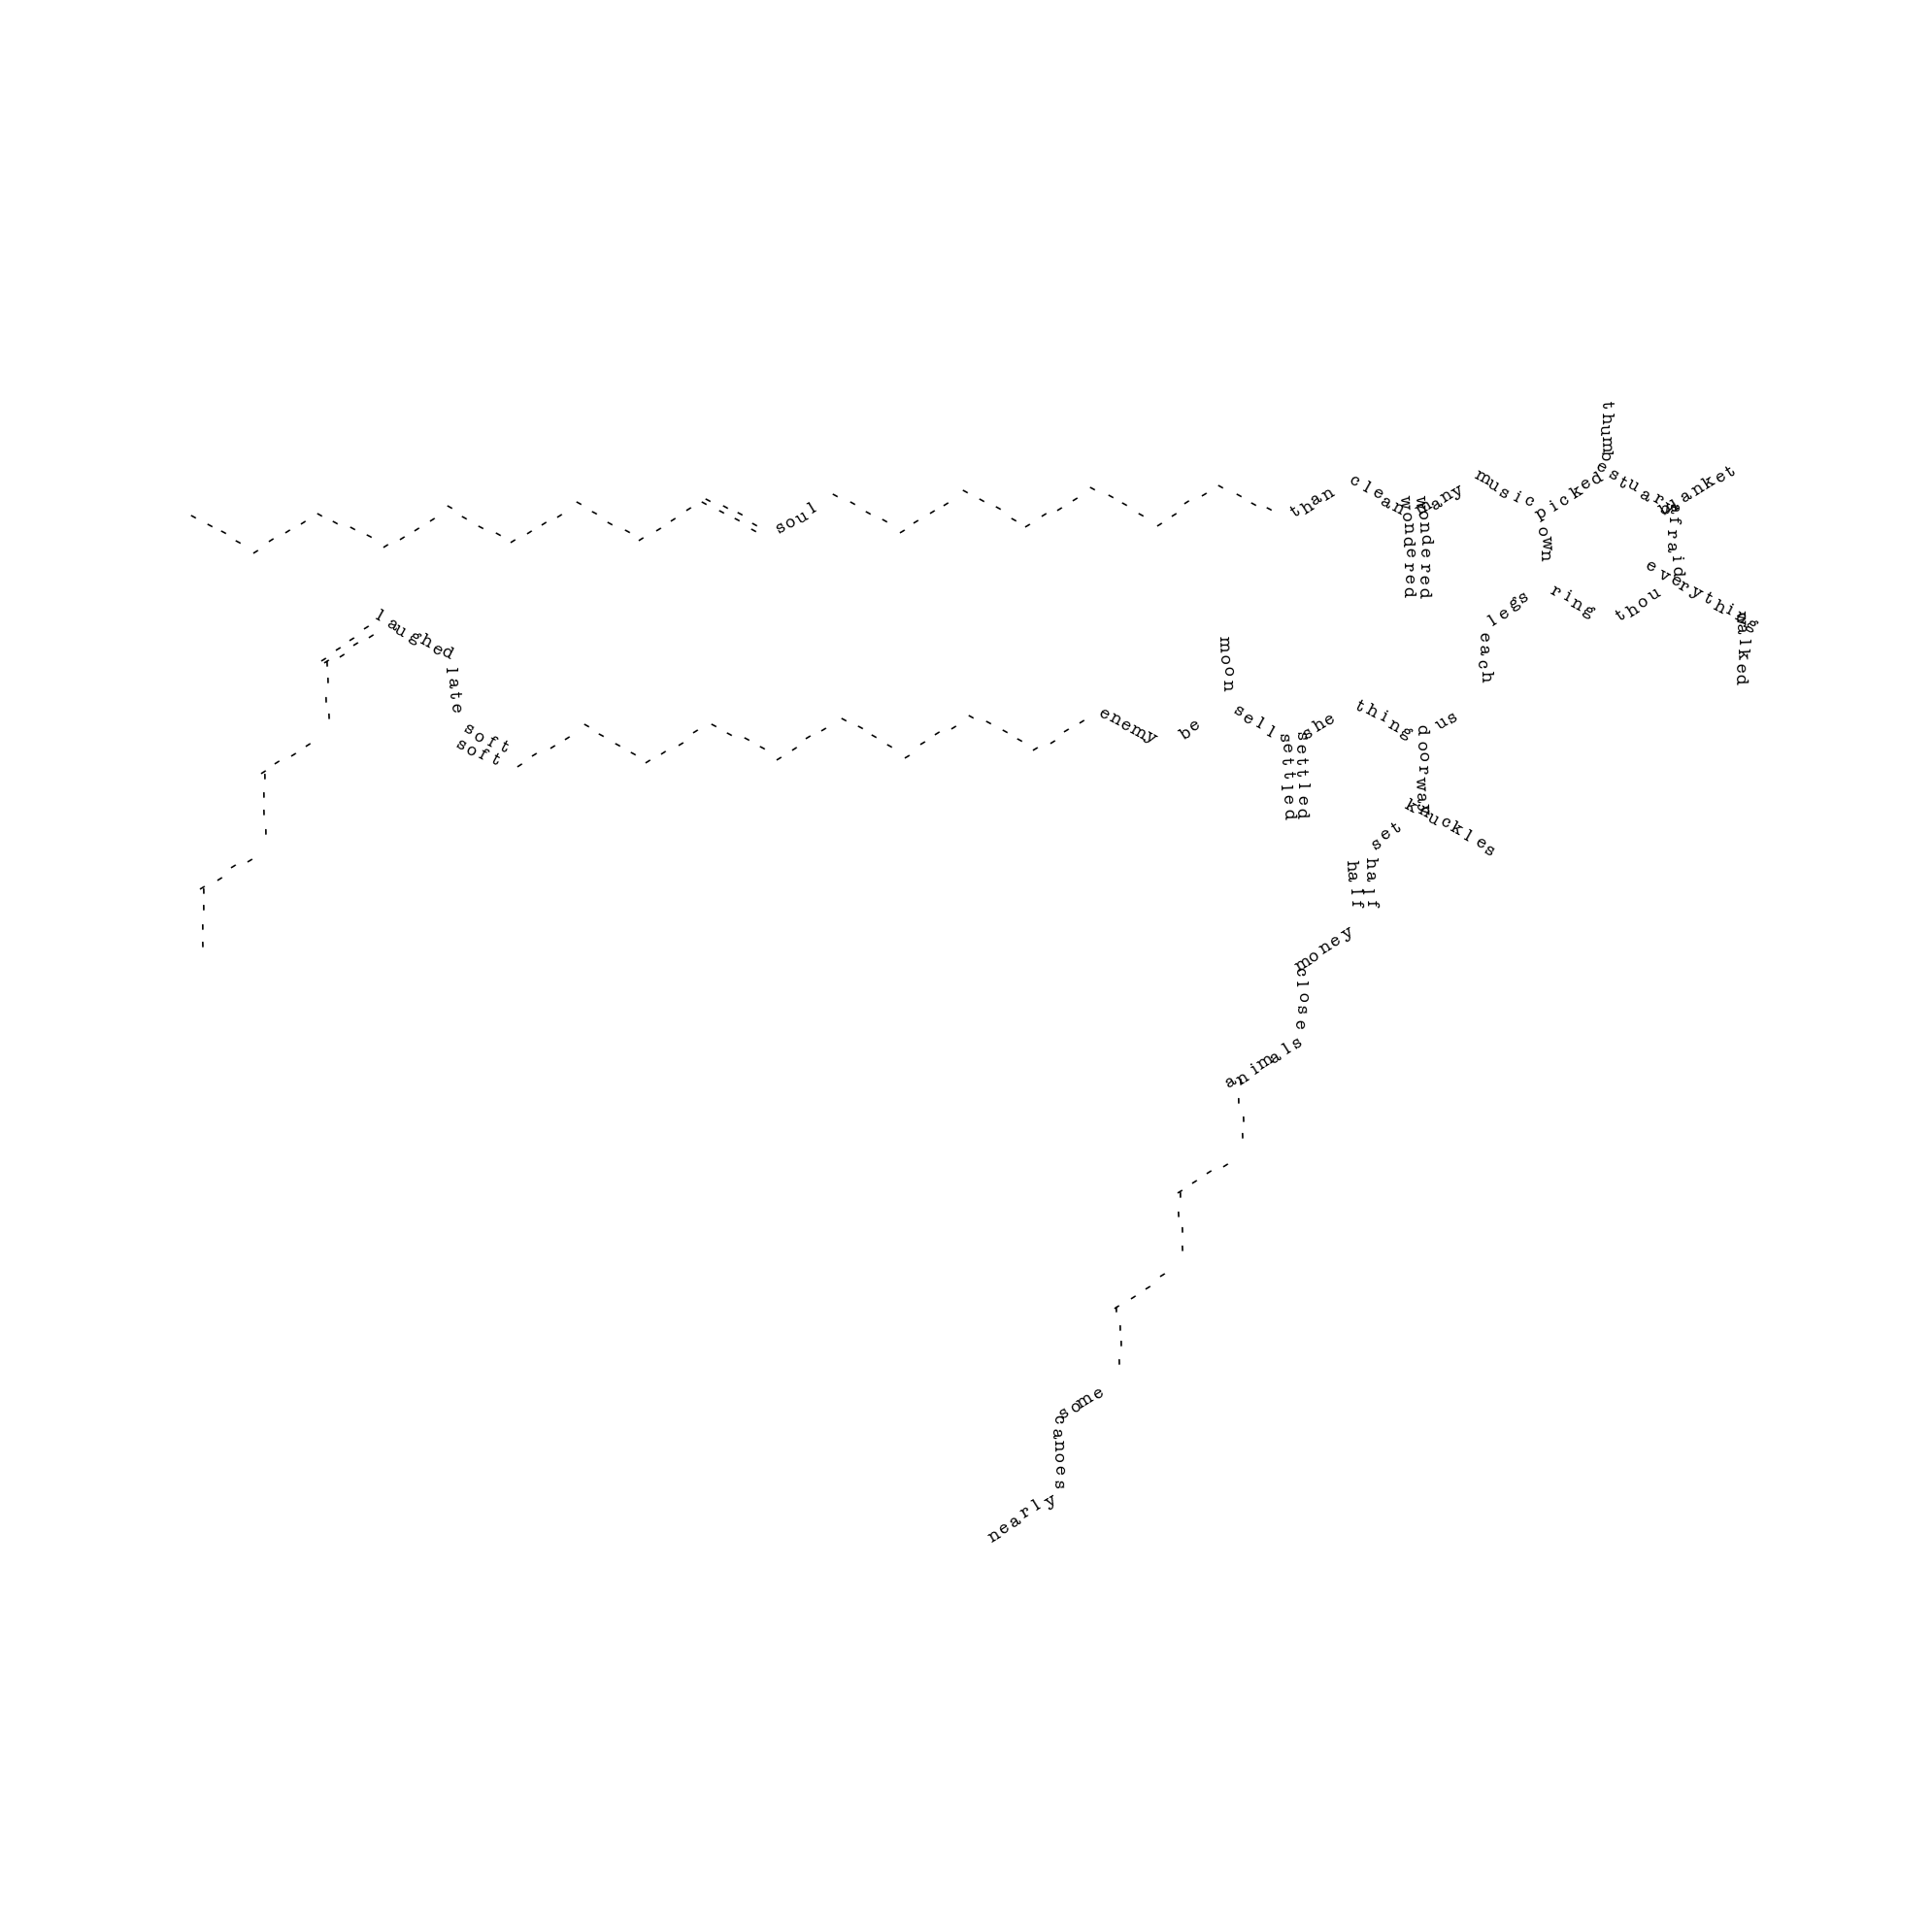

In [144]:
index = 1
# print(df.iloc[index]['smiles'])
# hybrid_word_bond_molecule(df.iloc[index]['smiles'], row_to_words(fps_array[index]))

# 1. With dashes (classic typewriter)
fig, mapping = typewriter_molecule_art_v2(
    smiles=df.iloc[index]['smiles'],
    letter_spacing=0.02,
    words_to_embed=row_to_words(fps_array[index]),
    target_length=20,
    spacing_char='',
    font_size=13,
    vertical_jitter=0.05,
    dashed_line_multiplier_for_bonds=3,
    letter_spacing_jitter=0.03,
    auto_scale=False
)
# plt.savefig('typewriter_dashes.png', dpi=300, bbox_inches='tight', facecolor='white')



[  23   33   90  147  284  285  296  297  301  314  334  341  356  364
  378  433  470  508  624  650  668  697  721  750  831  842  864  869
  926  974 1019]
[('from', 23), ('eyes', 33), ('who', 90), ('watched', 147), ('your', 284), ('mind', 285), ('past', 296), ('beat', 297), ('poison', 301), ('cave', 314), ('shell', 334), ('price', 341), ('followed', 356), ('edge', 364), ('dry', 378), ('line', 433), ('shirt', 470), ('fist', 508), ('ran', 624), ('arranged', 650), ('killed', 668), ('silver', 697), ('rising', 721), ('fiercely', 750), ('saying', 831), ('ropes', 842), ('sounded', 864), ('crossed', 869), ('nervous', 926), ('scuttled', 974), ('burning', 1019)]
scale_factor  0.5480484858633794  font_size  38.31777760852166
Mapped 14 words to 14 bonds
Bonds with words: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Bonds without words: []


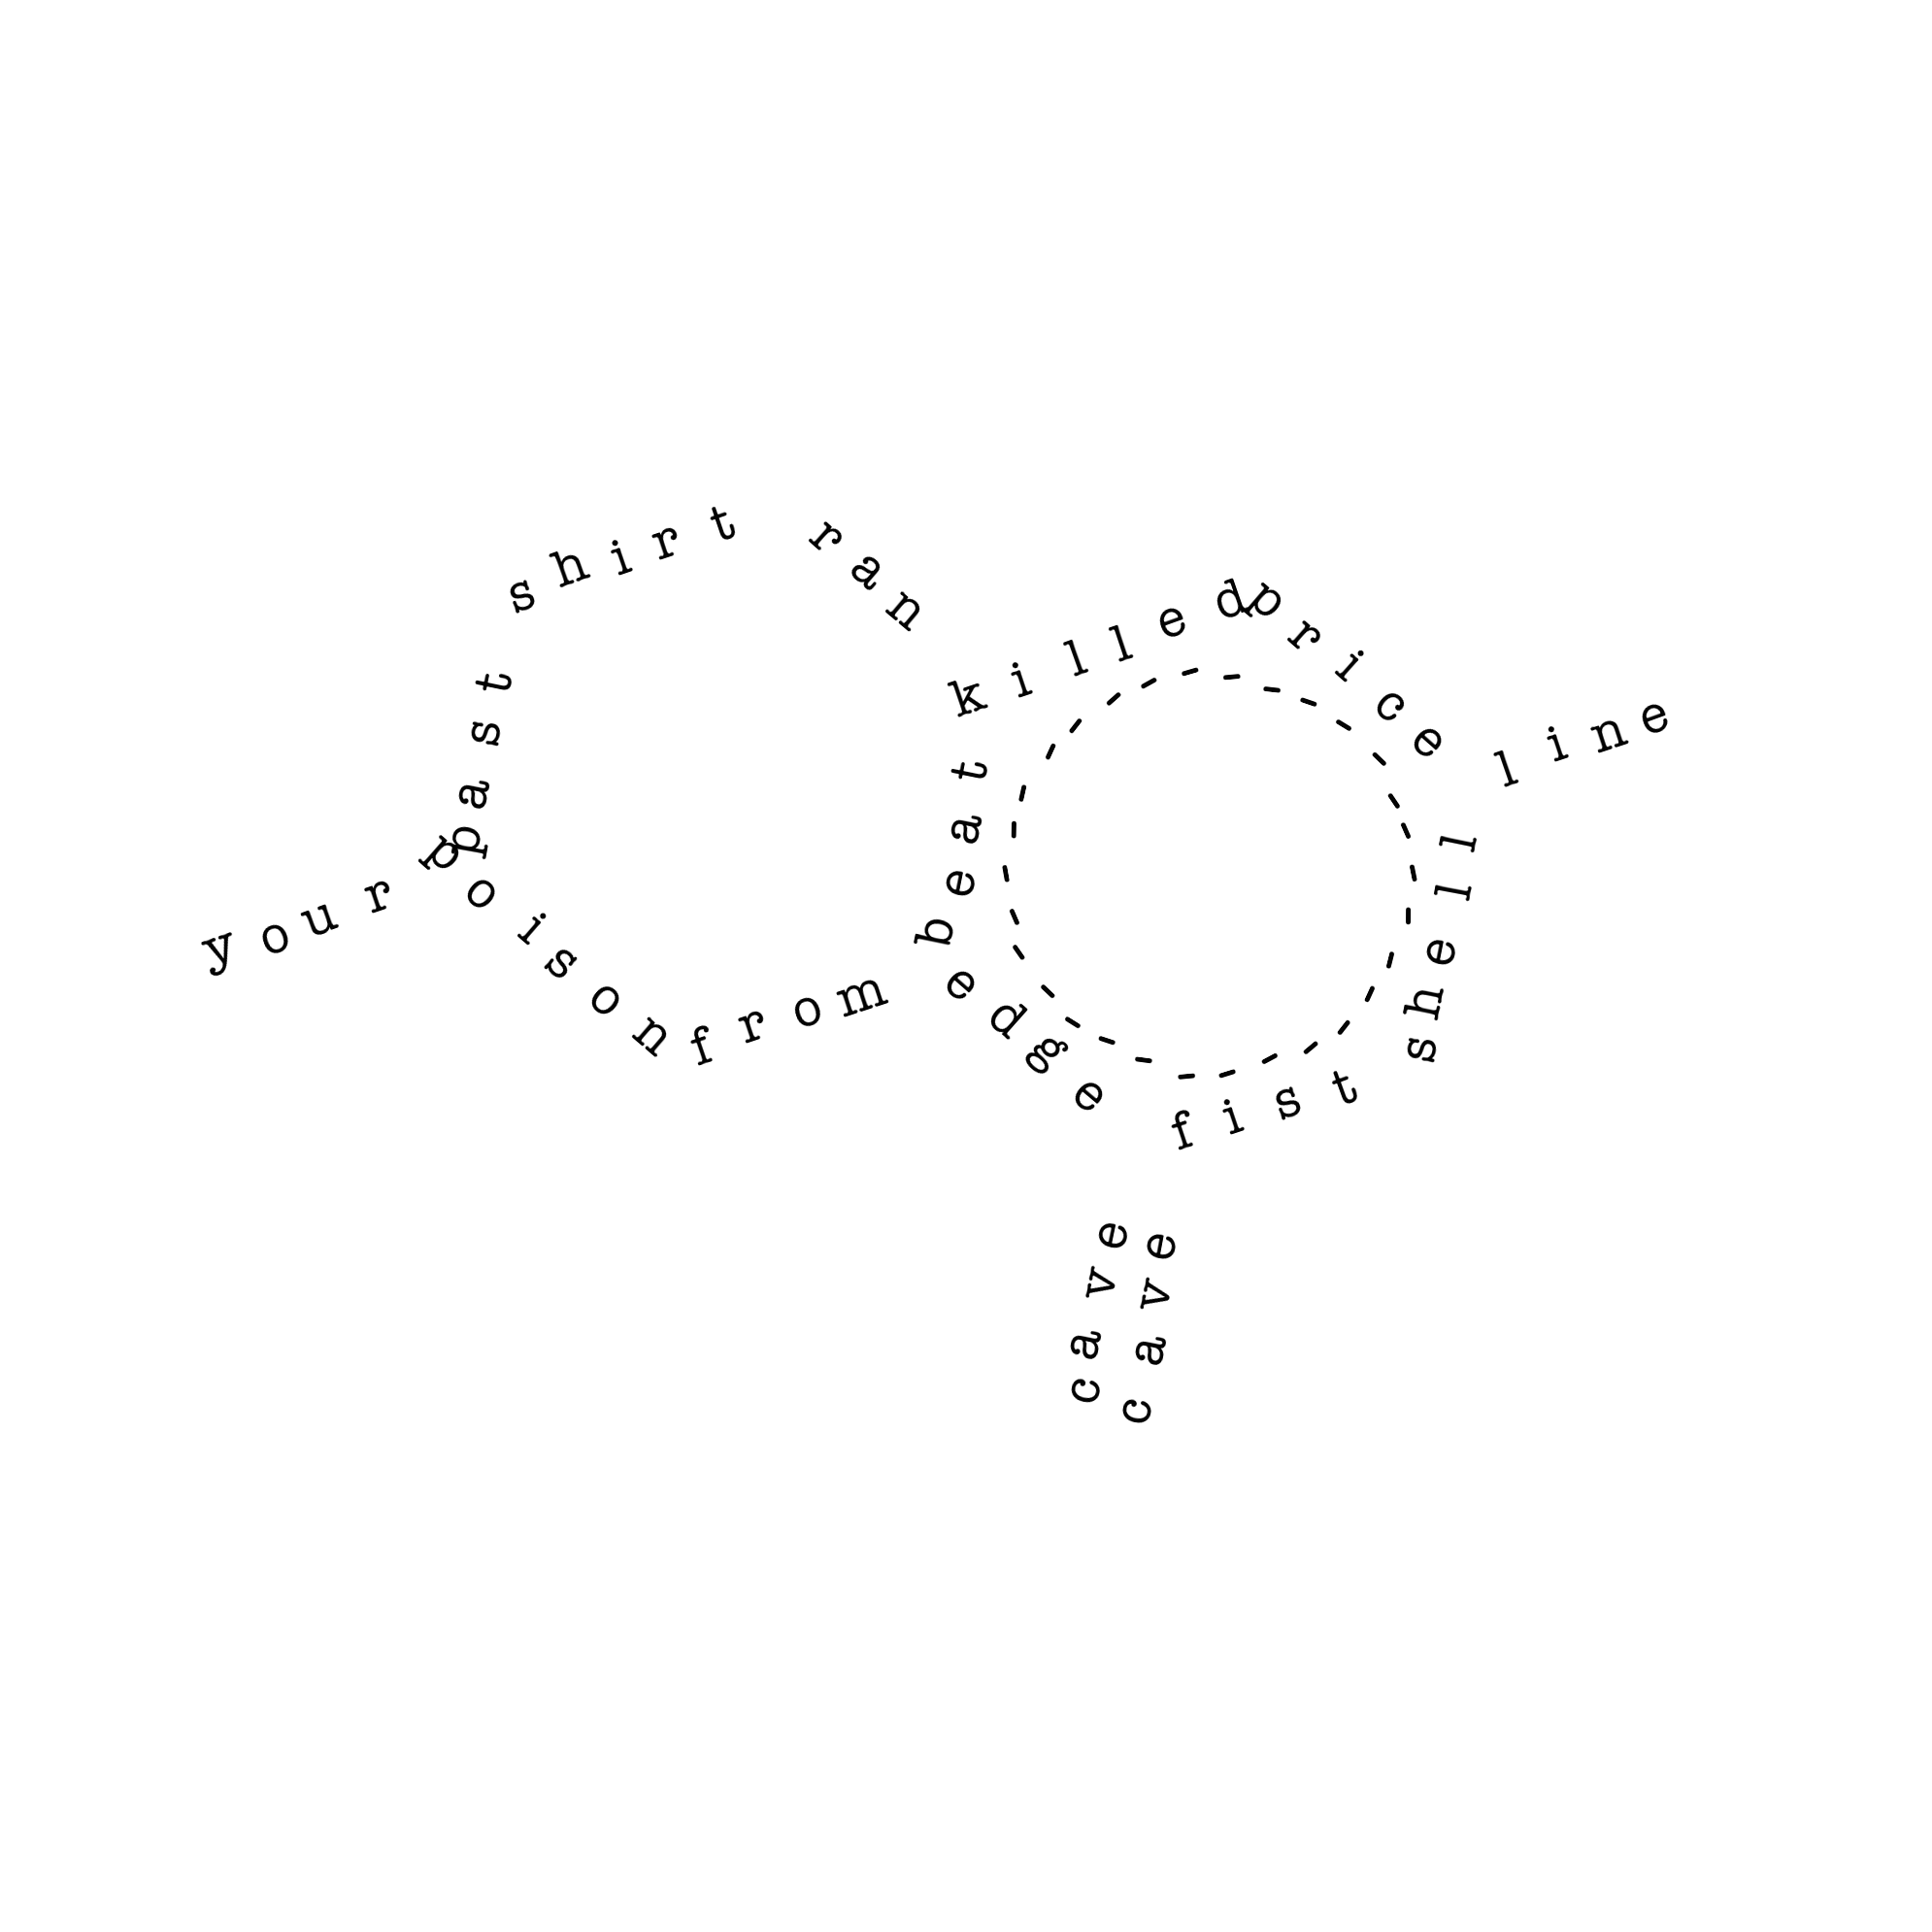

In [ ]:
index = 3
# print(df.iloc[index]['smiles'])
# hybrid_word_bond_molecule(df.iloc[index]['smiles'], row_to_words(fps_array[index]))

# 1. With dashes (classic typewriter)
fig, mapping = typewriter_molecule_art_v2(
    smiles=df.iloc[index]['smiles'],
    words_to_embed=row_to_words(fps_array[index]),
    target_length=20,
    spacing_char='',
    font_size=21,
    vertical_jitter=0.03,
    letter_spacing_jitter=0.03,
    letter_spacing=0.0075,
)
# plt.savefig('typewriter_dashes.png', dpi=300, bbox_inches='tight', facecolor='white')



[  0   1  33  69  72  75  80 115 116 147 200 283 316 389 403 409 425 505
 515 650 680 727 759 786 807 820 823 825 837 893 927 965]
[('the', 0), ('and', 1), ('eyes', 33), ('house', 69), ('by', 72), ('head', 75), ('people', 80), ('let', 115), ('moment', 116), ('watched', 147), ('mountains', 200), ('news', 283), ('wife', 316), ('waves', 389), ('should', 403), ('wild', 409), ('something', 425), ('tiny', 505), ('beggars', 515), ('arranged', 650), ('die', 680), ('drove', 727), ('attacked', 759), ('fool', 786), ('pools', 807), ('pit', 820), ('ends', 823), ('cakes', 825), ('tied', 837), ('although', 893), ('pulsing', 927), ('supper', 965)]
scale_factor  0.8543802184535294  font_size  24.57922075725377
Mapped 18 words to 21 bonds
Bonds with words: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 19]
Bonds without words: [17, 18, 20]


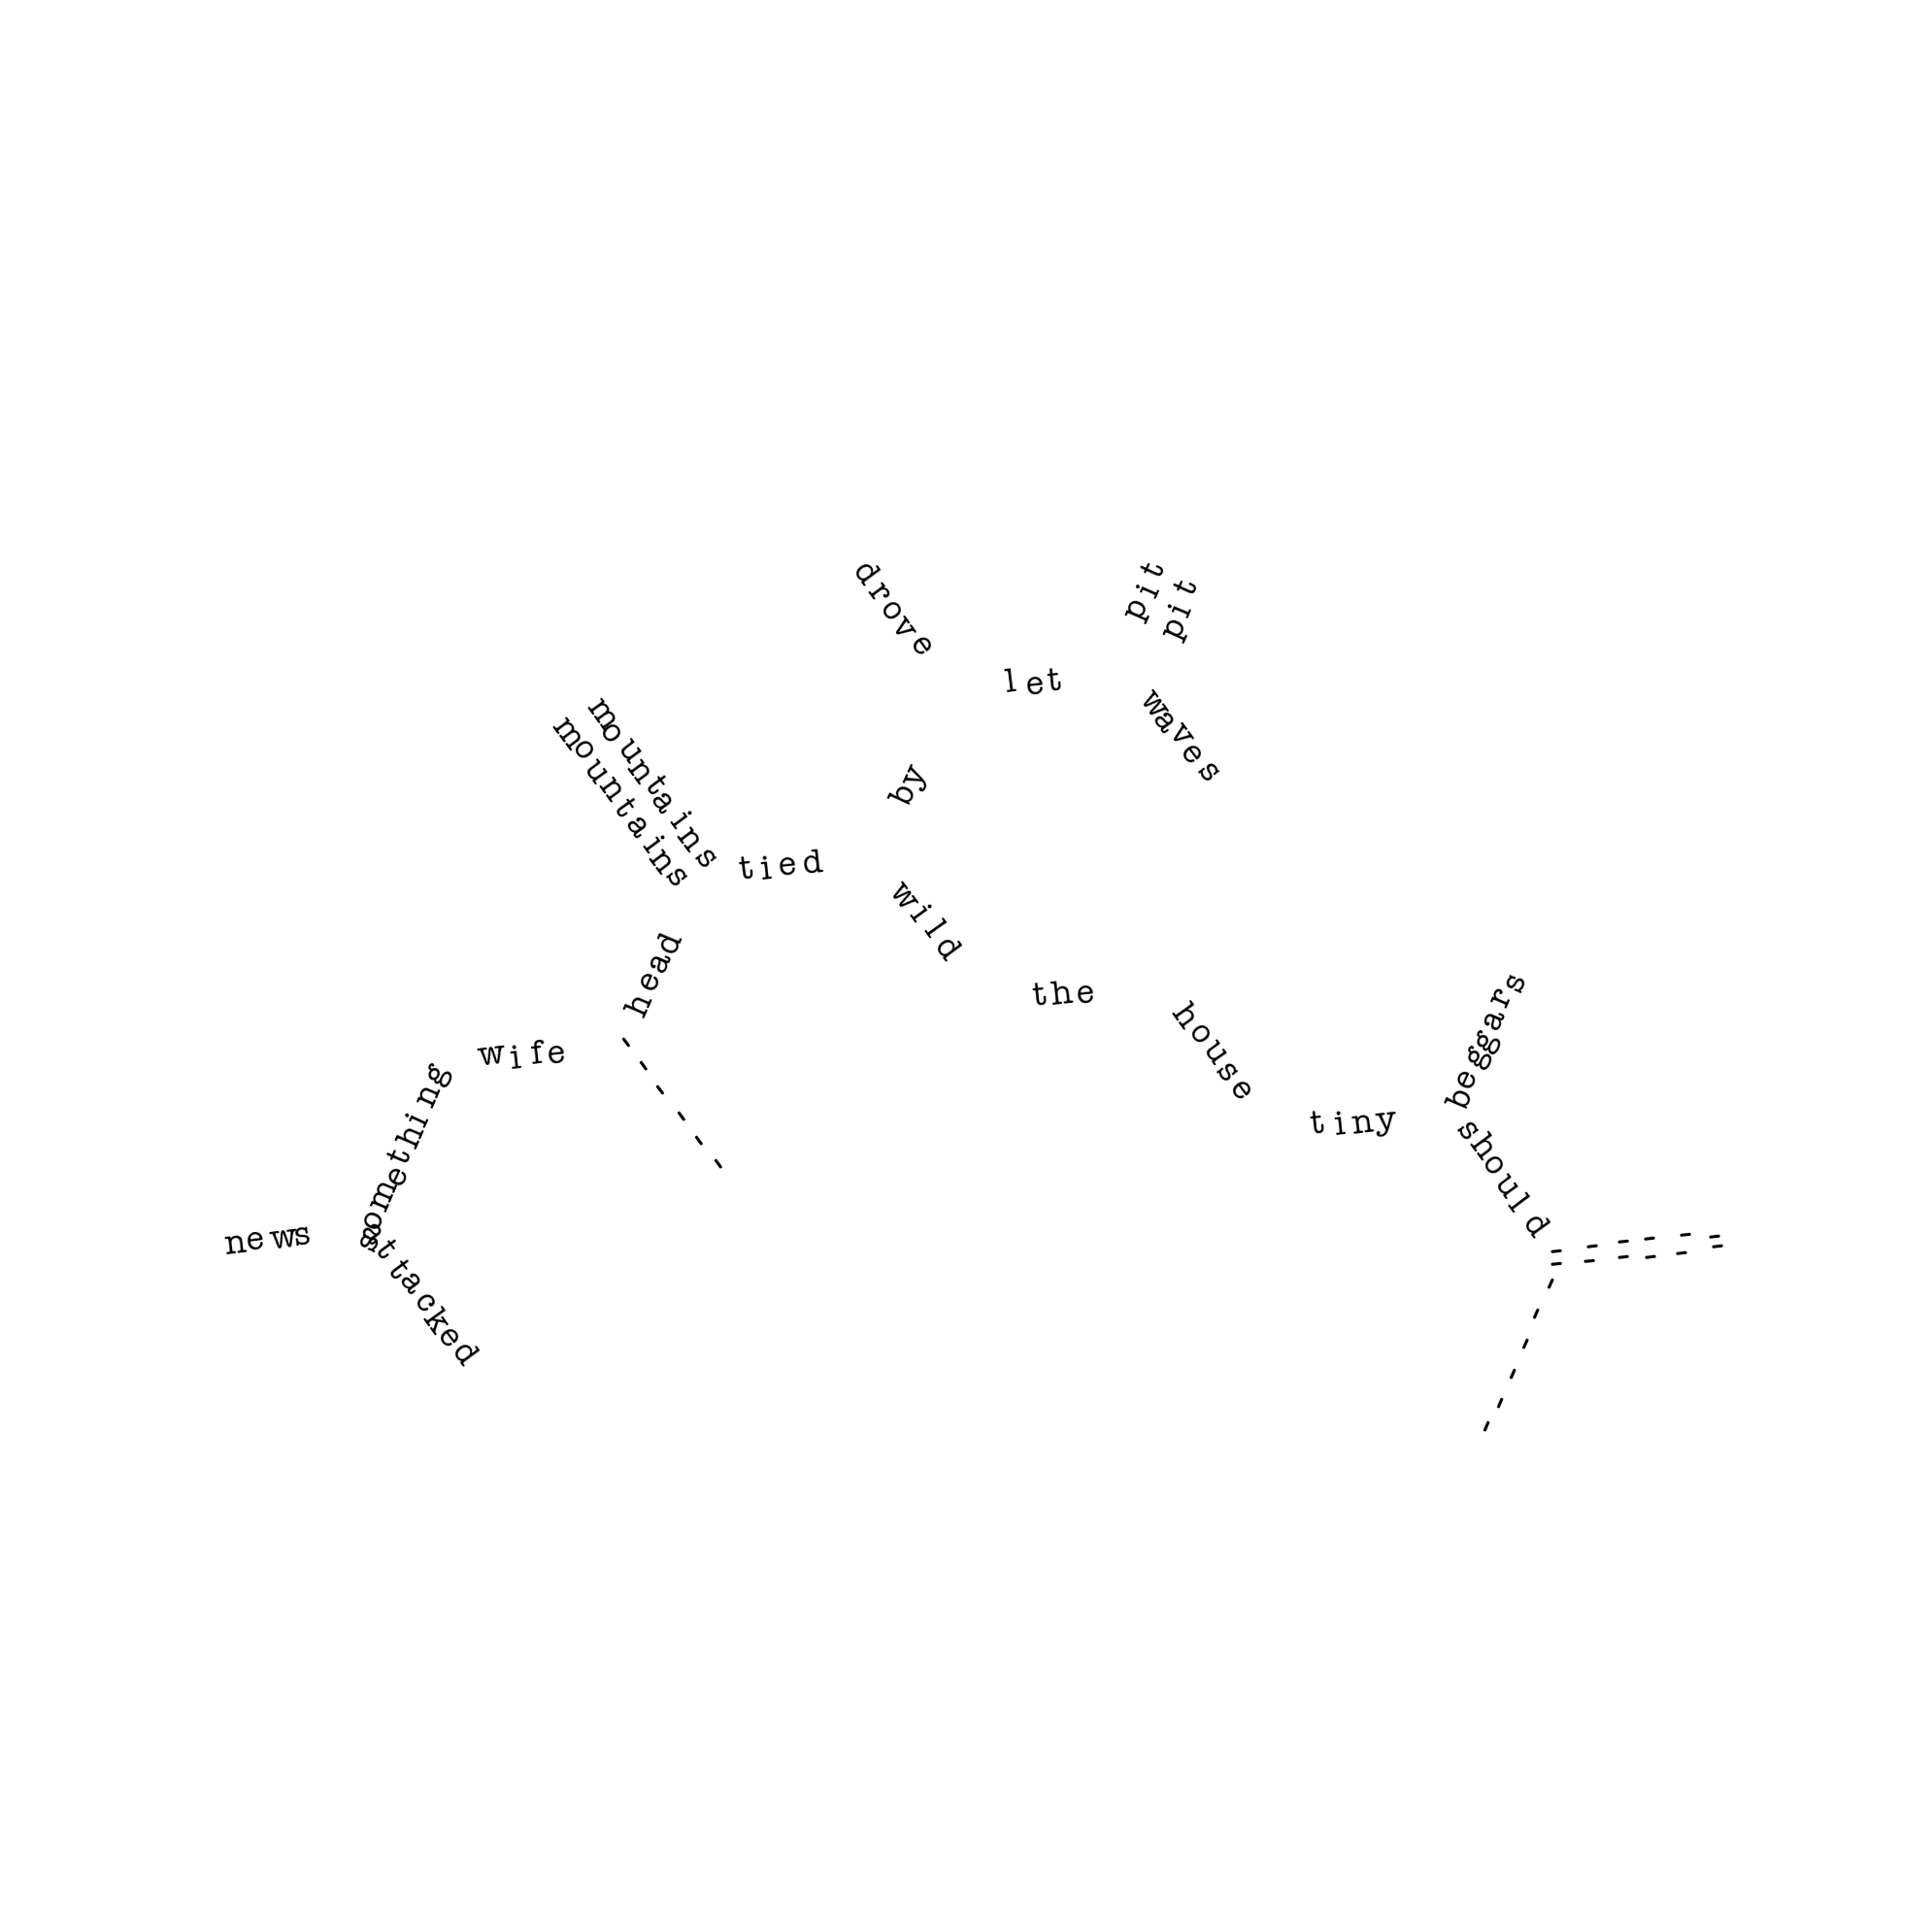

In [146]:
index = 4
# print(df.iloc[index]['smiles'])
# hybrid_word_bond_molecule(df.iloc[index]['smiles'], row_to_words(fps_array[index]))

# 1. With dashes (classic typewriter)
fig, mapping = typewriter_molecule_art_v2(
    smiles=df.iloc[index]['smiles'],
    words_to_embed=row_to_words(fps_array[index]),
    target_length=20,
    spacing_char='',
    font_size=21,
    vertical_jitter=0.03,
    letter_spacing_jitter=0.03,
    letter_spacing=0.0075,
)
# plt.savefig('typewriter_dashes.png', dpi=300, bbox_inches='tight', facecolor='white')



# LARGE


In [147]:
df[50:]

,Unnamed: 0,Cpd,Formula,RT,Mass,CAS_ID,Source,Score,Algorithm,RunName,name,smiles
55,55,3358,C6H9NO3,12.729,143.0579,NaN,FBF,87.20,FBF,large,"['3,5,5-trimethyl-1,3-oxazolidine-2,4-dione']",CC1(C(=O)N(C(=O)O1)C)C
56,56,2393,C46H86NO8P,14.678,811.6097,NaN,FBF,86.55,FBF,large,"['[(2R)-2-[(5Z,8Z,11Z)-icosa-5,8,11-trienoyl]o...",CCCCCCCCCCCCCCCCCC(=O)OC[C@H](COP(=O)([O-])OCC...
58,58,1316,C31H46O12S,12.651,642.2723,NaN,FBF,85.63,FBF,large,"['4-acetyl-6-[2-methoxy-3-(3-methoxy-2,2-dimet...",CCCCOC(=O)C(C)(C)CC.CC(=O)C1=CC(=C(C=C1C(=O)O)...
59,59,483,C24H38N2O,18.416,370.2971,NaN,FBF,85.18,FBF,large,"['1-cyclohexyl-4-[3-(5-methoxy-1,2,3,4-tetrahy...",COC1=CC=CC2=C1CCCC2CCCN3CCN(CC3)C4CCCCC4
60,60,4086,C37H75NO3,16.261,581.5771,NaN,FBF,84.87,FBF,large,"['N-[(2S,3R)-1,3-dihydroxyoctadecan-2-yl]nonad...",CCCCCCCCCCCCCCCCCCC(=O)N[C@@H](CO)[C@@H](CCCCC...
...,...,...,...,...,...,...,...,...,...,...,...,...
195,195,251,C8H6O5,0.435,182.0209,NaN,FBF,80.84,FBF,tiny,"['5-hydroxybenzene-1,3-dicarboxylic acid']",C1=C(C=C(C=C1C(=O)O)O)C(=O)O
196,196,5909,C7H14S2,1.396,162.0525,NaN,FBF,80.74,FBF,tiny,['2-[[(E)-prop-1-enyl]disulfanyl]butane'],CCC(C)SS/C=C/C
197,197,3013,C27H46O10,5.192,530.3104,NaN,FBF,80.73,FBF,tiny,"['(3R,5S,6S,7R,8S,9R,12R,13R,14S,15R)-6,14-dih...",C[C@H]1C[C@@]2(CO2)C(=O)[C@@H]([C@H]([C@H]([C@...
198,198,445,C8H17NO2,0.383,159.1273,NaN,FBF,80.42,FBF,tiny,['(3S)-3-(aminomethyl)-5-methylhexanoic acid'],CC(C)C[C@@H](CC(=O)O)CN


[ 33  36  60 121 185 250 255 258 314 324 356 566 576 608 650 656 723 935
 987]
[('eyes', 33), ('you', 36), ('go', 60), ('while', 121), ('canoe', 185), ('dealer', 250), ('slipped', 255), ('drew', 258), ('cave', 314), ('quietly', 324), ('followed', 356), ('sucked', 566), ('thumb', 576), ('books', 608), ('arranged', 650), ('sang', 656), ('thus', 723), ('really', 935), ('changed', 987)]
scale_factor  0.33957385791333095  font_size  47.117879151002434
Mapped 10 words to 10 bonds
Bonds with words: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Bonds without words: []


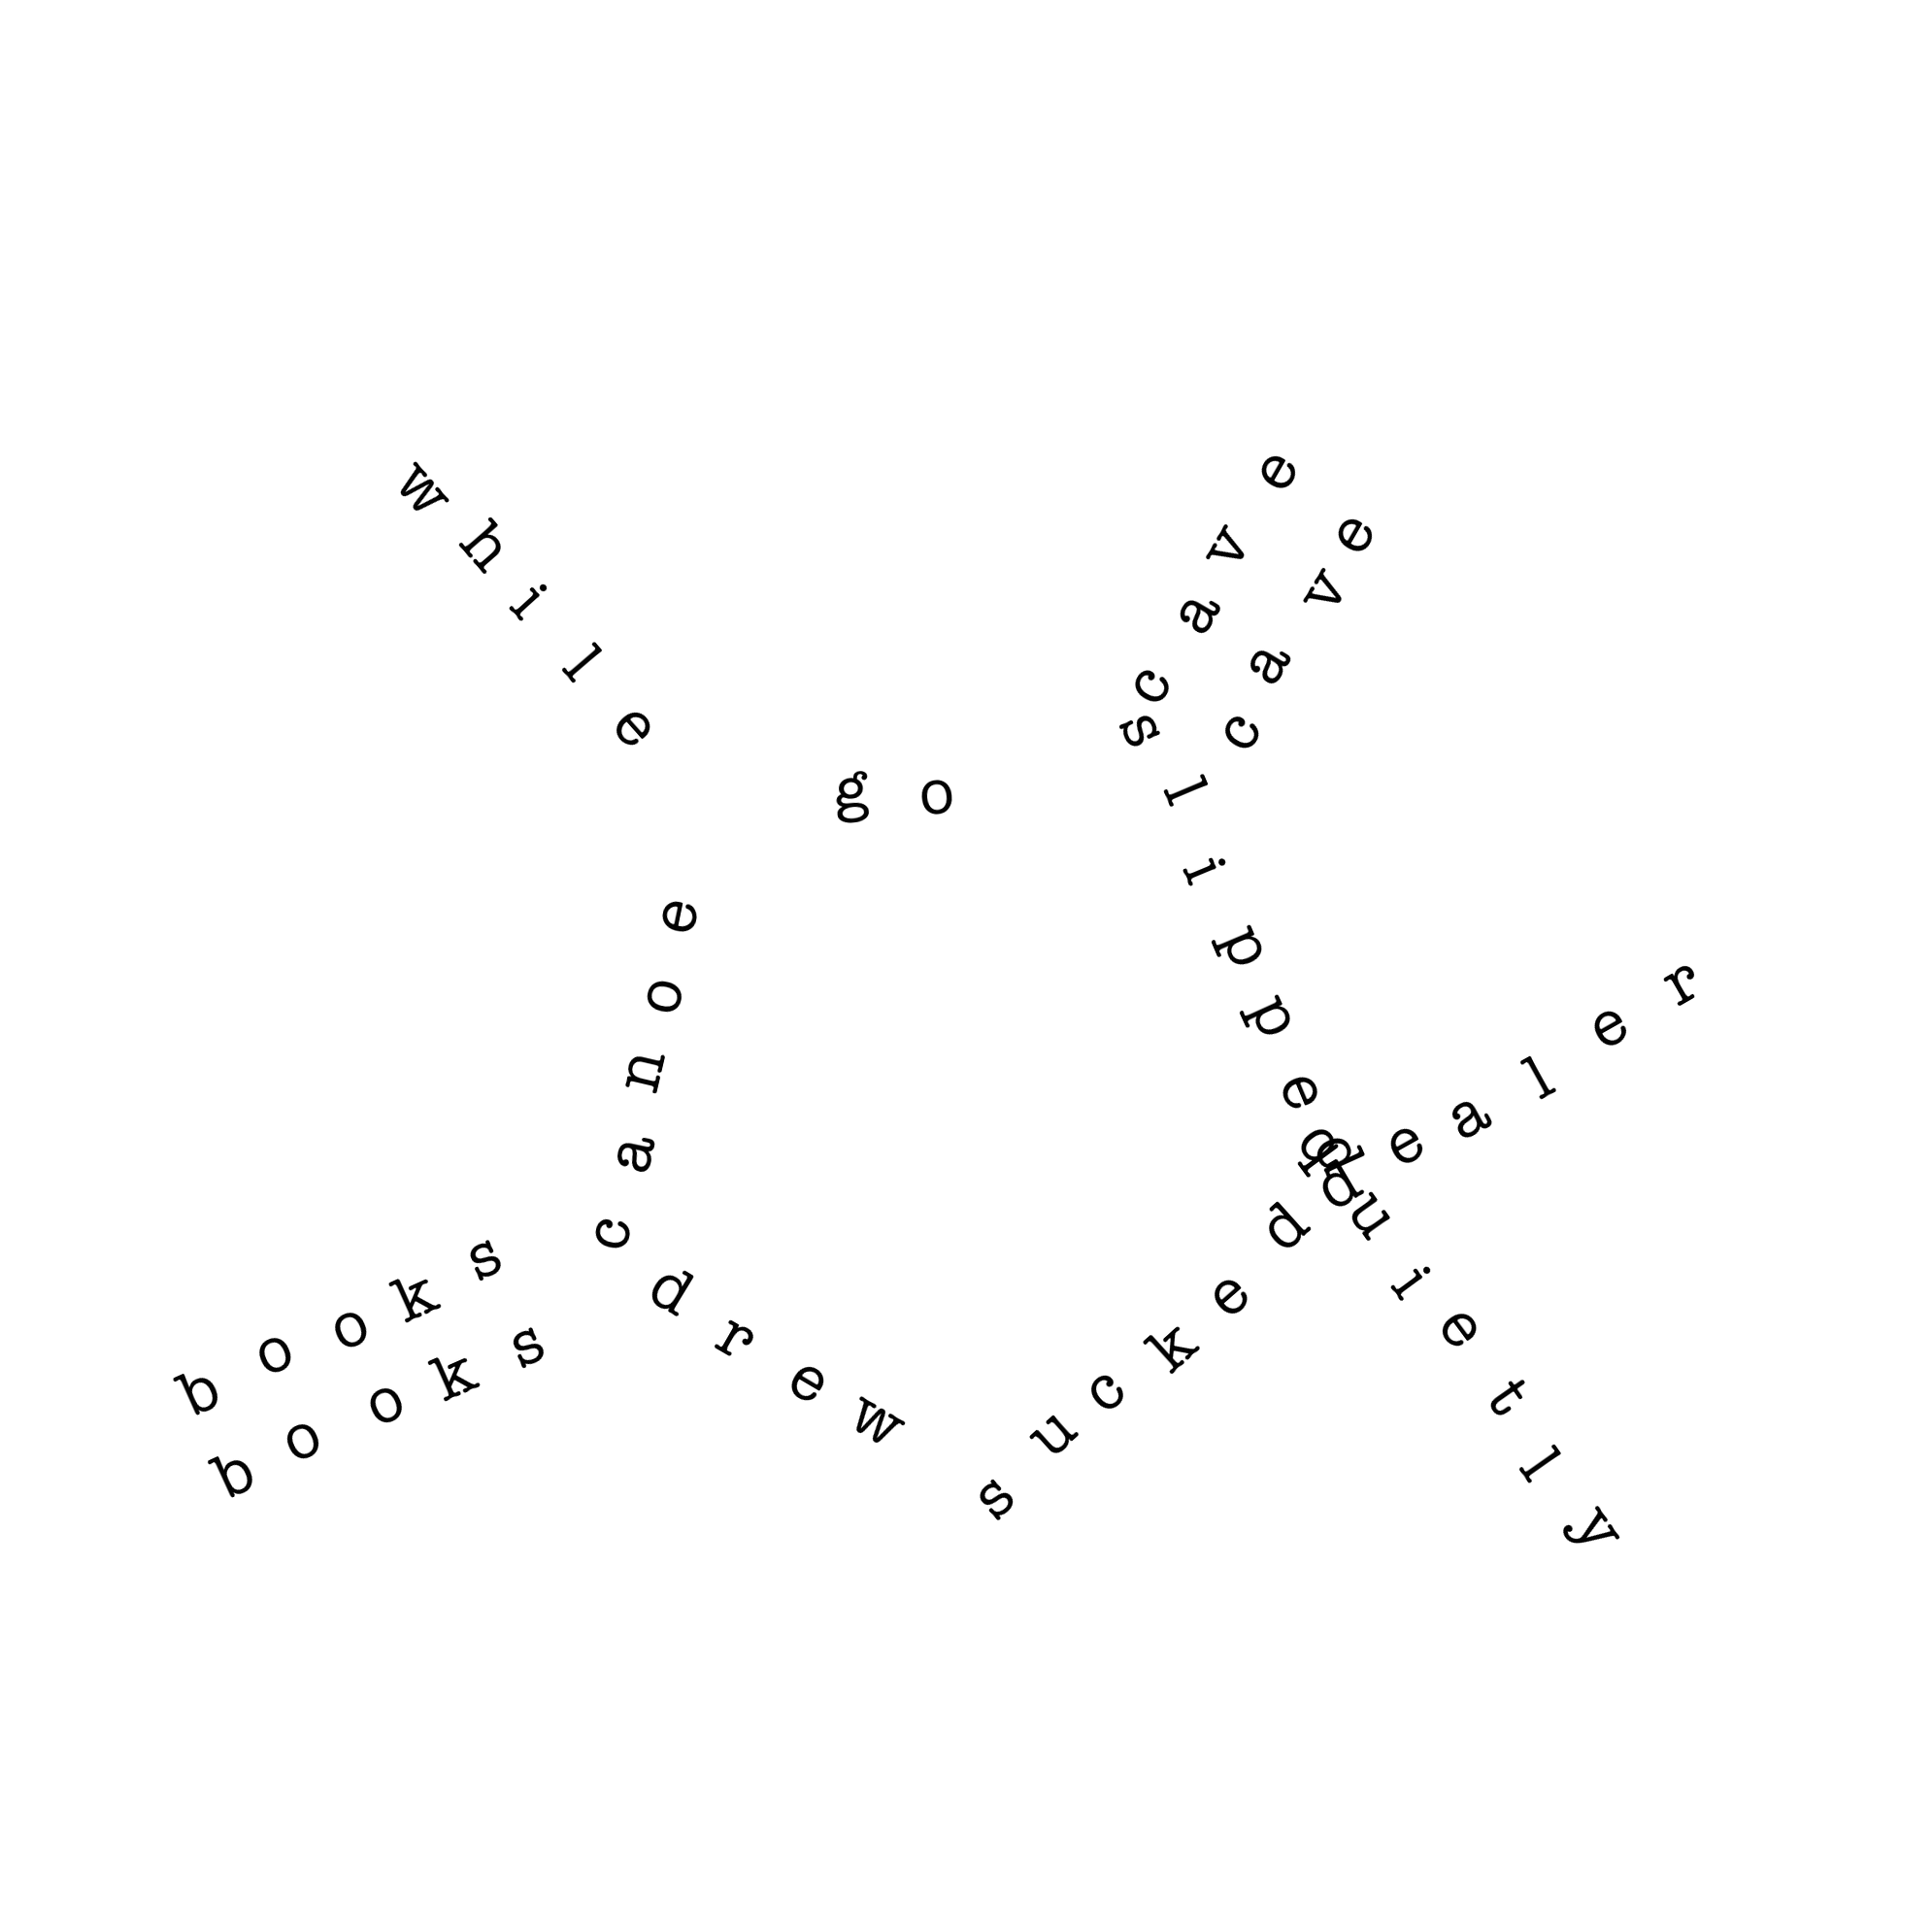

In [148]:
index = 50
# print(df.iloc[index]['smiles'])
# hybrid_word_bond_molecule(df.iloc[index]['smiles'], row_to_words(fps_array[index]))

# 1. With dashes (classic typewriter)
fig, mapping = typewriter_molecule_art_v2(
    smiles=df.iloc[index]['smiles'],
    words_to_embed=row_to_words(fps_array[index]),
    target_length=20,
    spacing_char='',
    font_size=16,
    vertical_jitter=0.03,
    letter_spacing_jitter=0.03,
    letter_spacing=0.0055,
)
# plt.savefig('typewriter_dashes.png', dpi=300, bbox_inches='tight', facecolor='white')


[  1  10  13  33  69  80 118 119 125 147 171 192 194 243 294 299 319 332
 336 362 375 401 414 416 417 420 479 486 534 540 563 568 573 579 591 595
 628 637 646 650 677 692 694 695 715 729 731 775 794 807 849 887 893 913
 991]
[('and', 1), ('they', 10), ('with', 13), ('eyes', 33), ('house', 69), ('people', 80), ('us', 118), ('some', 119), ('family', 125), ('watched', 147), ('soft', 171), ('last', 192), ('sand', 194), ('than', 243), ('nearly', 294), ('legs', 299), ('word', 319), ('money', 332), ('oyster', 336), ('many', 362), ('doorway', 375), ('close', 401), ('shadow', 414), ('animals', 416), ('hat', 417), ('canoes', 420), ('stirred', 479), ('peered', 486), ('considered', 534), ('clean', 540), ('bright', 563), ('four', 568), ('together', 573), ('rise', 579), ('destroyed', 591), ('pulled', 595), ('evening', 628), ('roosters', 637), ('late', 646), ('arranged', 650), ('swelling', 677), ('kill', 692), ('inches', 694), ('home', 695), ('rubble', 715), ('moments', 729), ('soul', 731), ('whisper

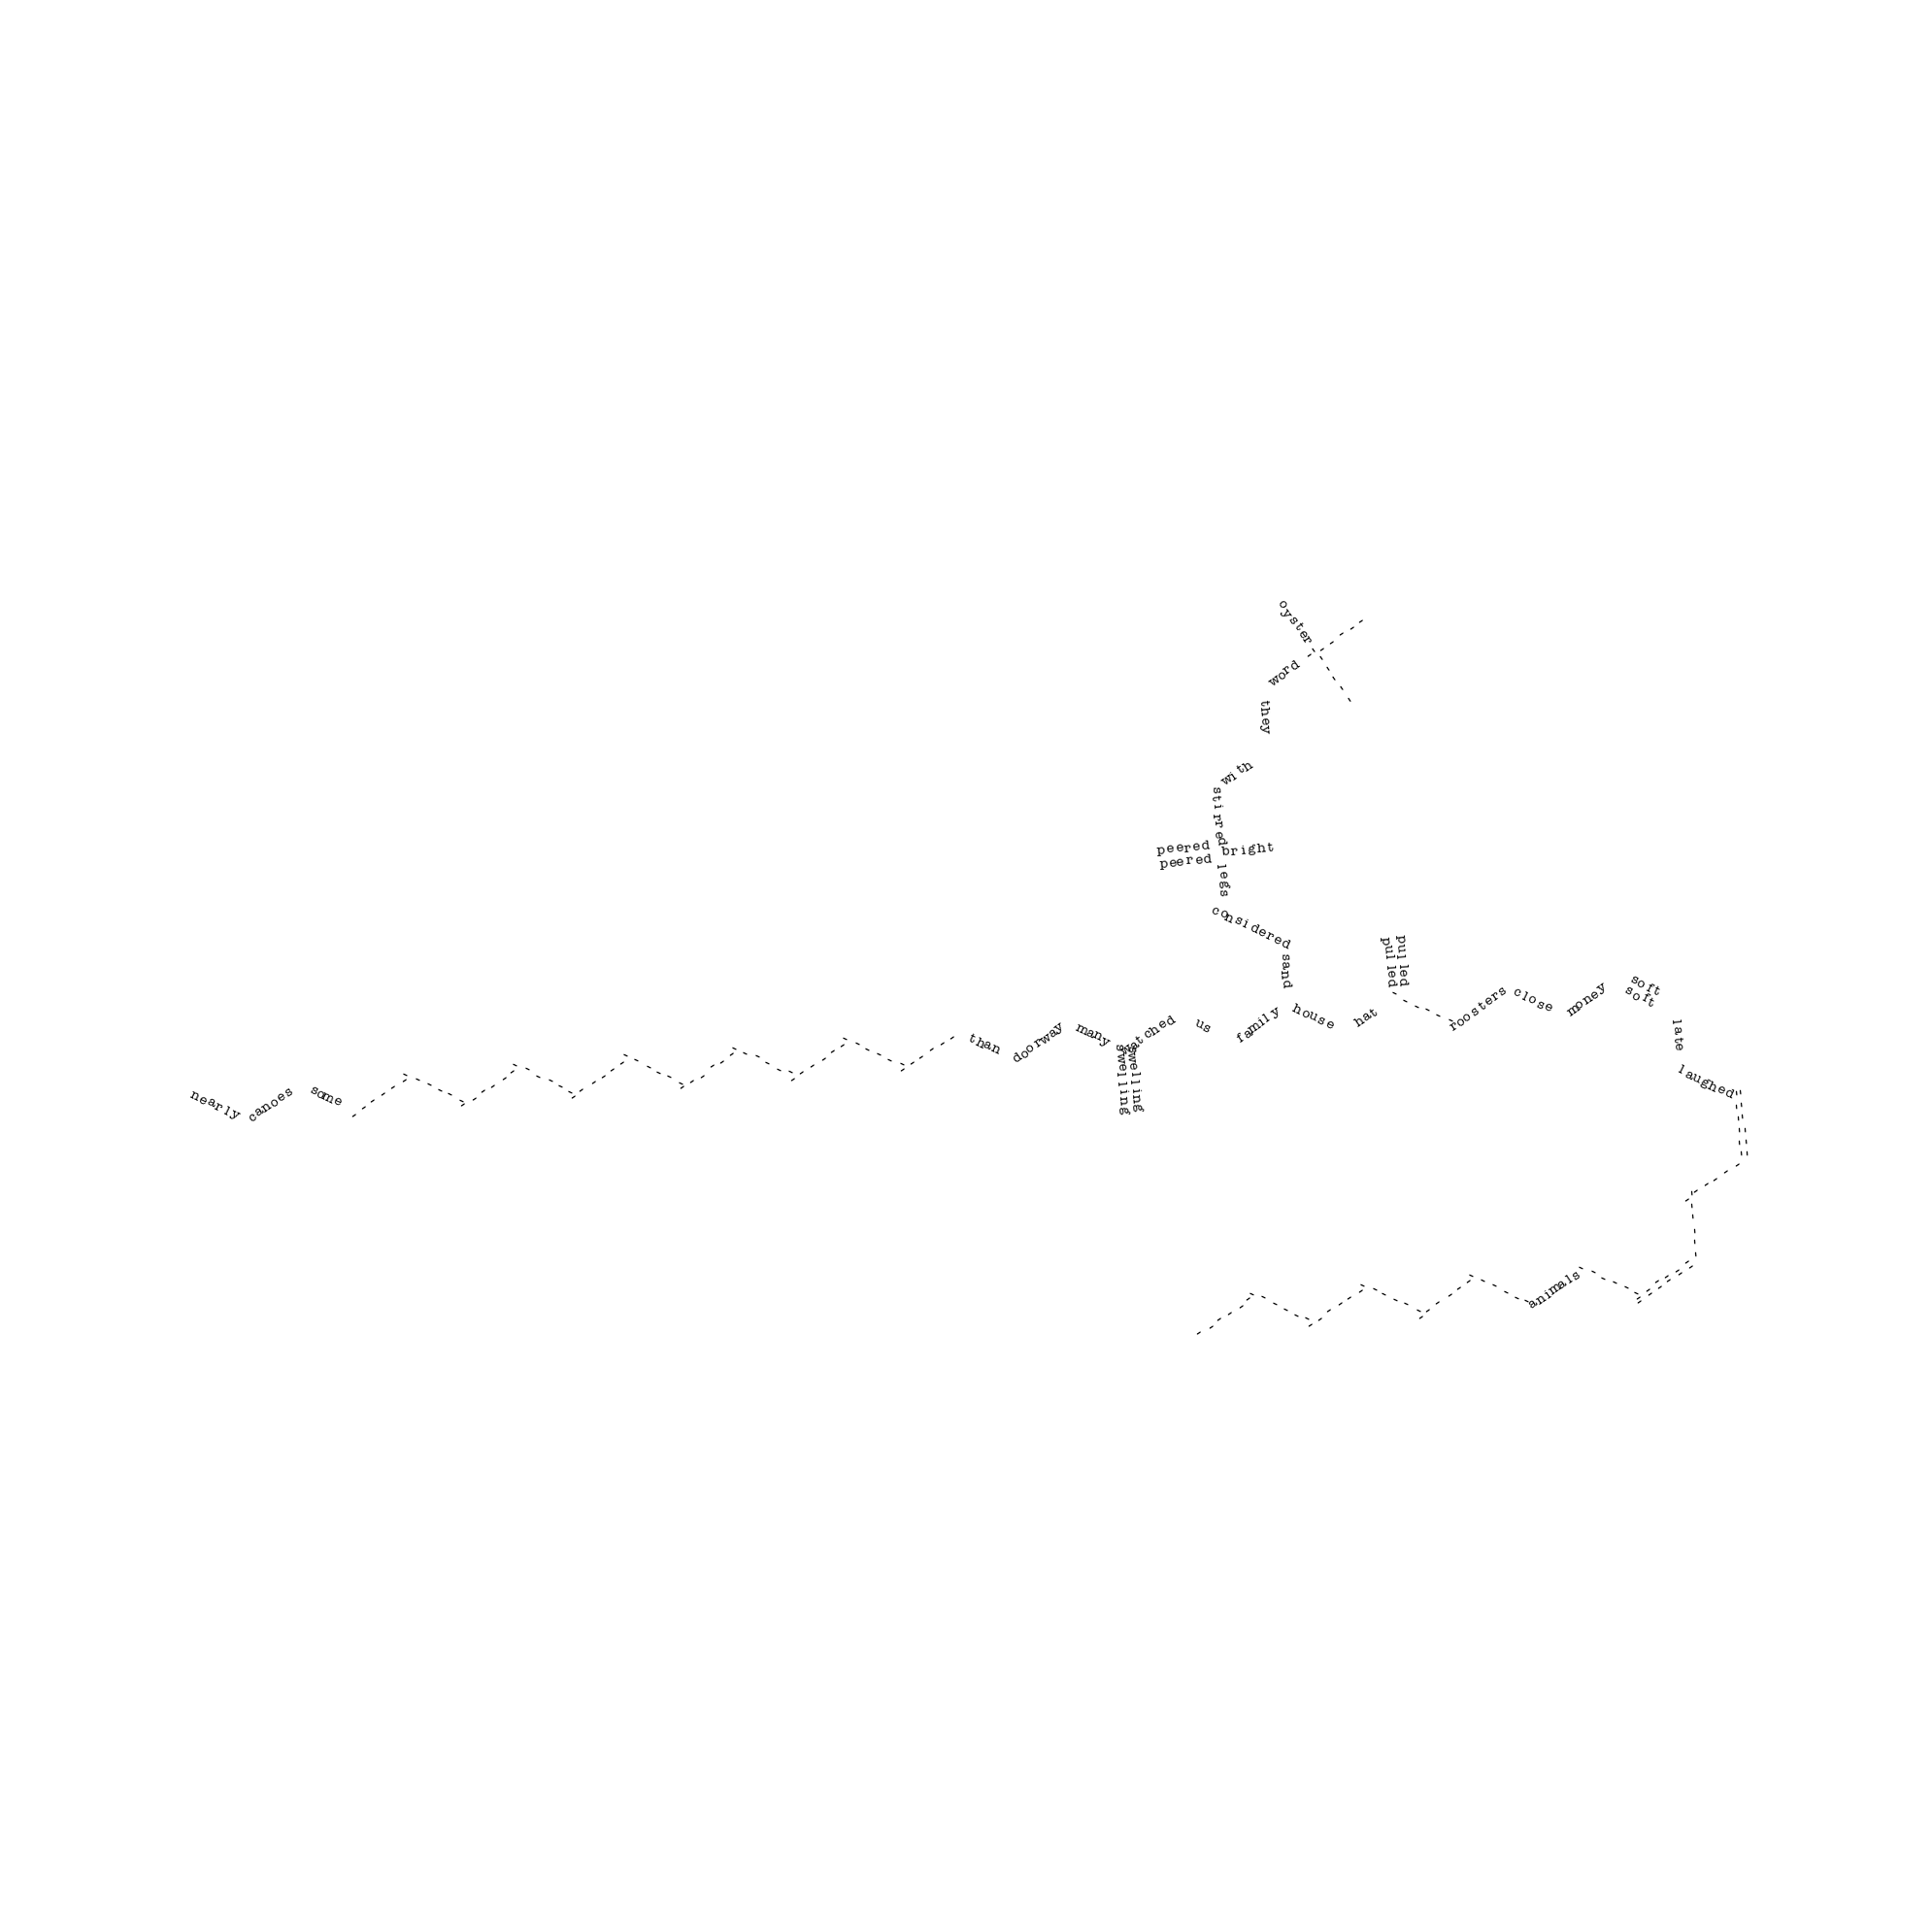

In [149]:
index = 51
# print(df.iloc[index]['smiles'])
# hybrid_word_bond_molecule(df.iloc[index]['smiles'], row_to_words(fps_array[index]))

# 1. With dashes (classic typewriter)
fig, mapping = typewriter_molecule_art_v2(
    smiles=df.iloc[index]['smiles'],
    words_to_embed=row_to_words(fps_array[index]),
    target_length=25,
    spacing_char='',
    font_size=25,
    vertical_jitter=0.03,
    letter_spacing_jitter=0.03,
    letter_spacing=0.020,
)
# plt.savefig('typewriter_dashes.png', dpi=300, bbox_inches='tight', facecolor='white')


[   1    2   13   23   27   33   69   70   80   87  114  116  118  125
  128  145  147  294  295  327  356  389  392  446  456  457  492  500
  510  519  567  574  591  649  650  695  701  710  718  726  727  754
  794  796  799  807  841  849  861  875  887  893  915  953  954  967
  991 1002 1017]
[('and', 1), ('of', 2), ('with', 13), ('from', 23), ('but', 27), ('eyes', 33), ('house', 69), ('great', 70), ('people', 80), ('light', 87), ('put', 114), ('moment', 116), ('us', 118), ('family', 125), ('black', 128), ('very', 145), ('watched', 147), ('nearly', 294), ('body', 295), ('better', 327), ('followed', 356), ('waves', 389), ('bare', 392), ('cold', 446), ('read', 456), ('race', 457), ('everything', 492), ('ancient', 500), ('entrance', 510), ('heavy', 519), ('fat', 567), ('bed', 574), ('destroyed', 591), ('frantically', 649), ('arranged', 650), ('home', 695), ('rested', 701), ('shame', 710), ('clung', 718), ('continued', 726), ('drove', 727), ('whisper', 754), ('bring', 794), ('moving

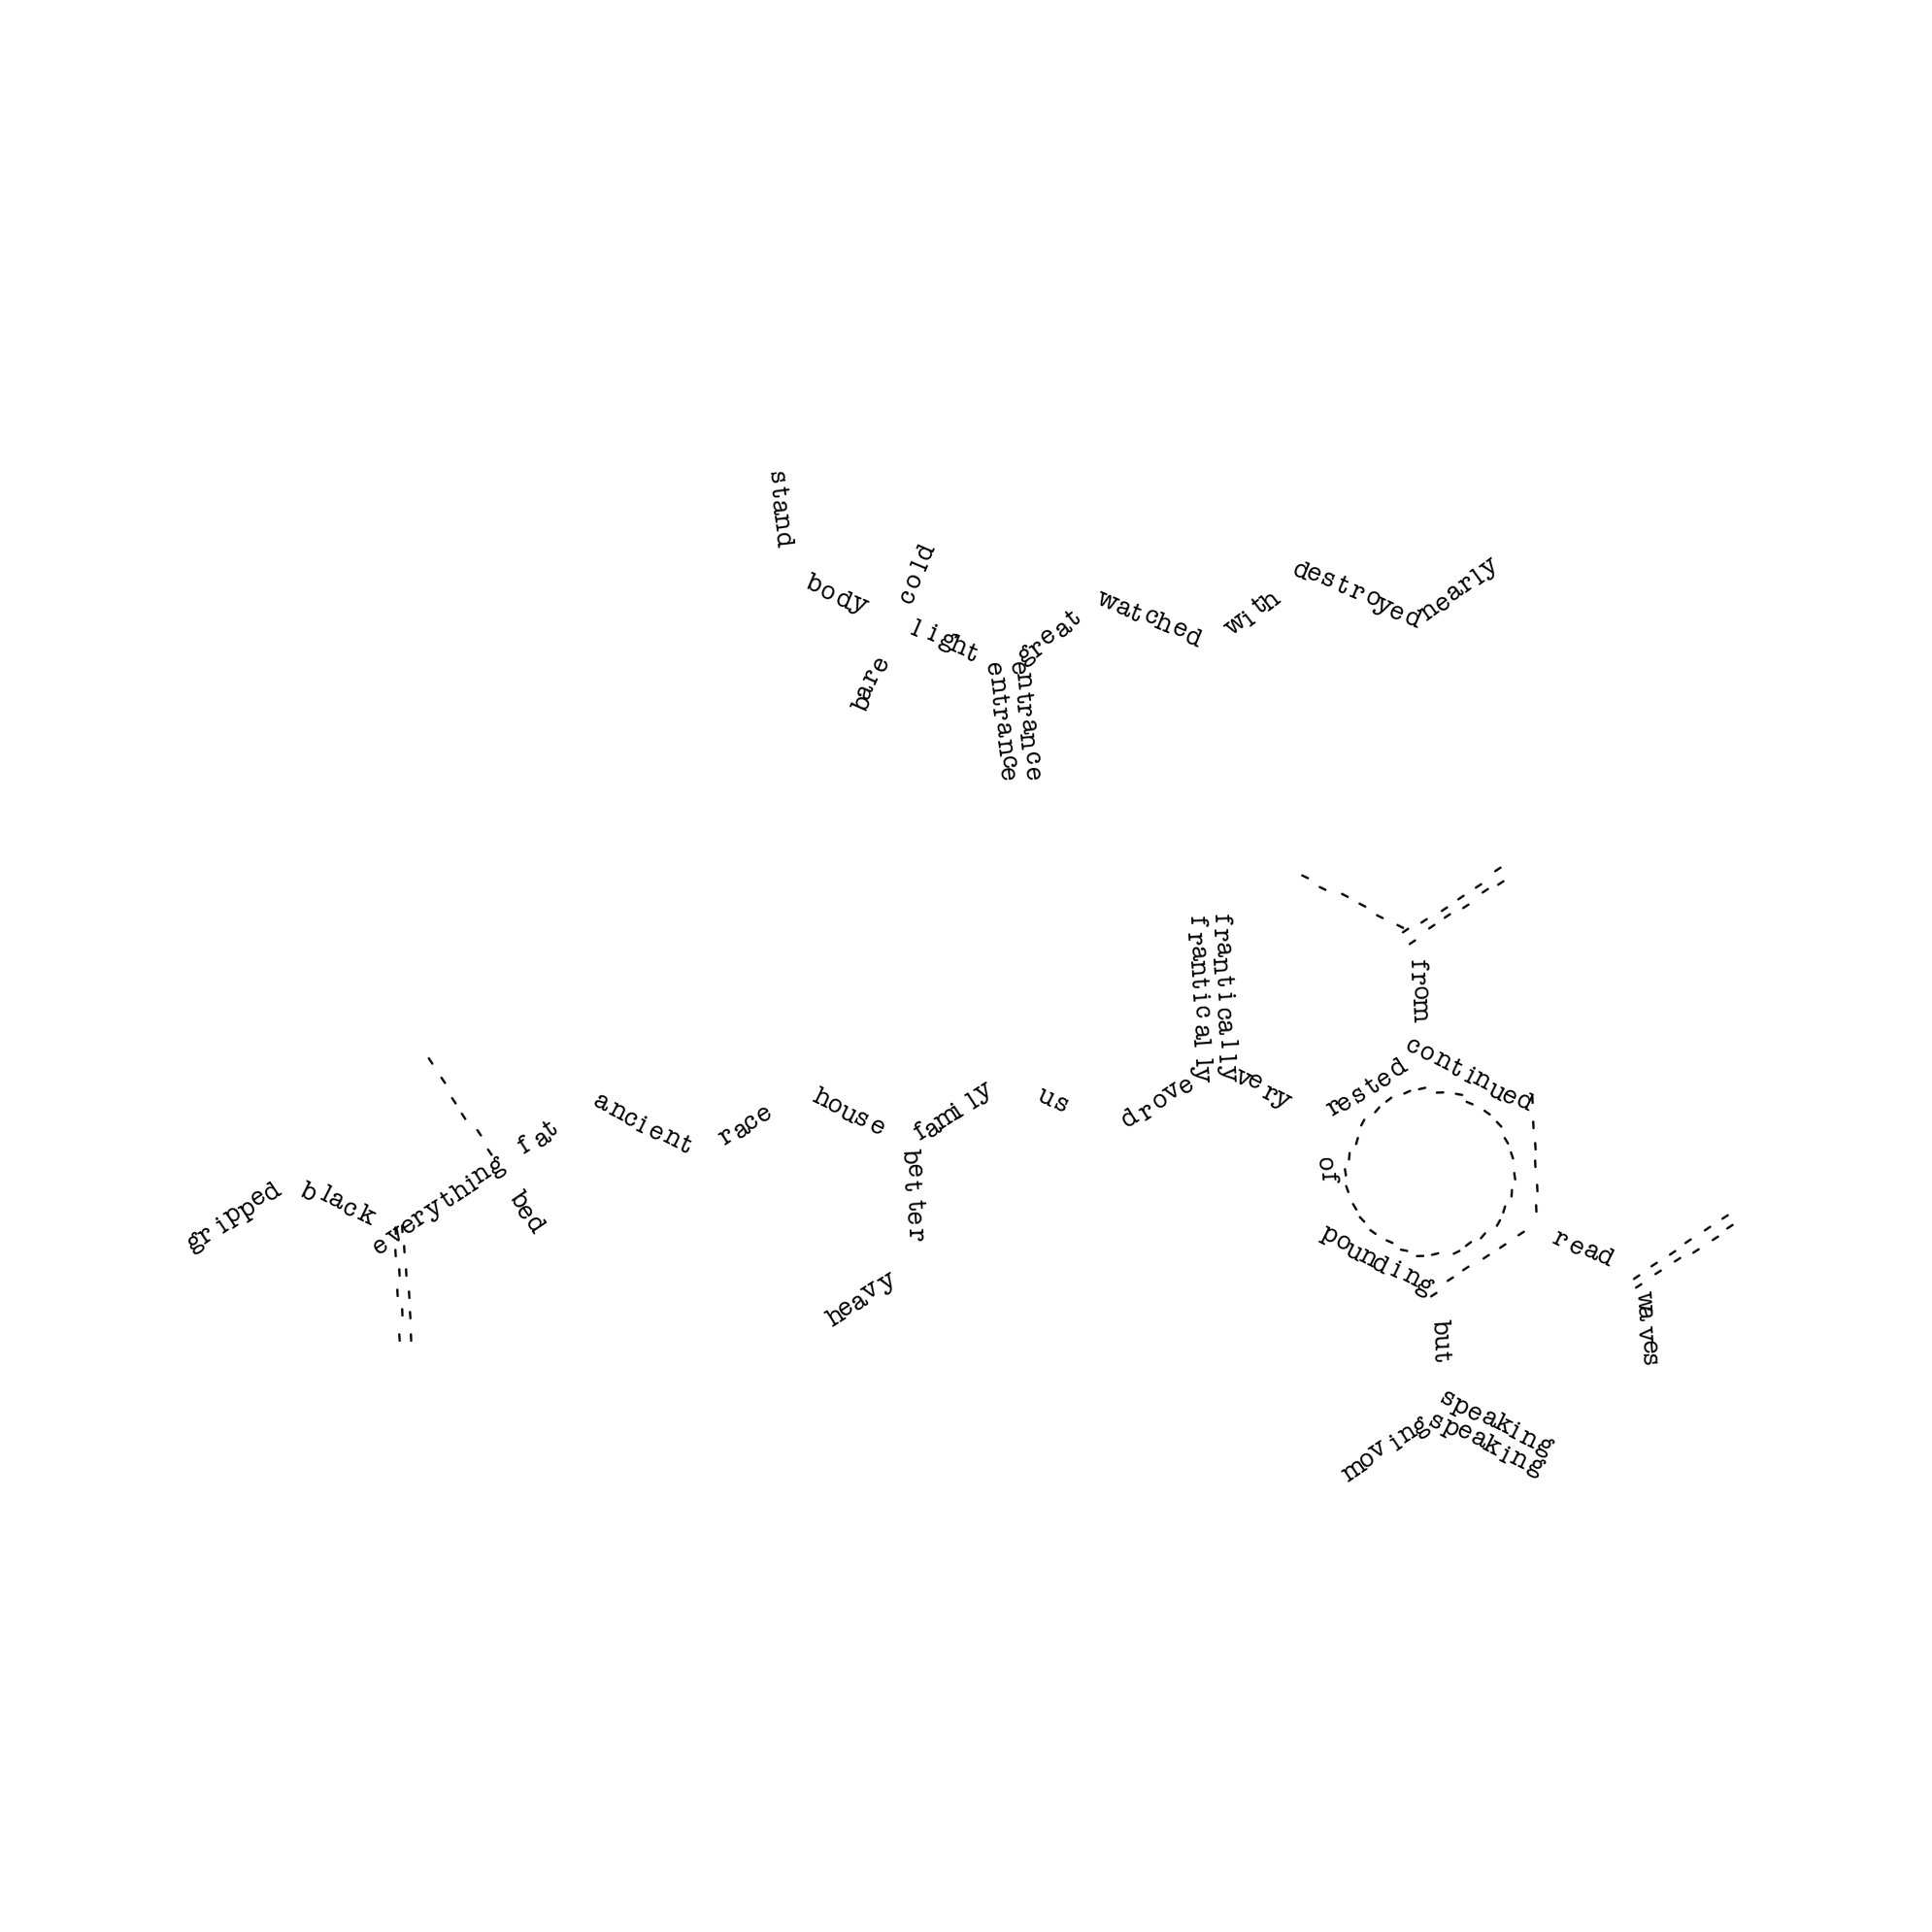

In [150]:
index = 52
# print(df.iloc[index]['smiles'])
# hybrid_word_bond_molecule(df.iloc[index]['smiles'], row_to_words(fps_array[index]))

# 1. With dashes (classic typewriter)
fig, mapping = typewriter_molecule_art_v2(
    smiles=df.iloc[index]['smiles'],
    words_to_embed=row_to_words(fps_array[index]),
    target_length=25,
    spacing_char='',
    font_size=25,
    vertical_jitter=0.03,
    letter_spacing_jitter=0.03,
    letter_spacing=0.01,
)
# plt.savefig('typewriter_dashes.png', dpi=300, bbox_inches='tight', facecolor='white')


[   2    3    4   15   33   64   74   80   88  121  182  249  282  301
  356  361  367  371  386  440  456  458  473  512  558  576  587  593
  651  653  695  712  713  714  726  767  830  832  841  849  886  887
  890  926  935  946  969 1019]
[('of', 2), ('a', 3), ('he', 4), ('little', 15), ('eyes', 33), ('knew', 64), ('only', 74), ('people', 80), ('or', 88), ('while', 121), ('felt', 182), ('wind', 249), ('distance', 282), ('poison', 301), ('followed', 356), ('servant', 361), ('basket', 367), ('sell', 371), ('slept', 386), ('alone', 440), ('read', 456), ('though', 458), ('picked', 473), ('going', 512), ('curled', 558), ('thumb', 576), ('touched', 587), ('tightly', 593), ('chin', 651), ('perfect', 653), ('home', 695), ('whose', 712), ('making', 713), ('bow', 714), ('continued', 726), ('working', 767), ('creak', 830), ('warmth', 832), ('crevices', 841), ('laughed', 849), ('folded', 886), ('valueless', 887), ('stern', 890), ('nervous', 926), ('really', 935), ('shrilling', 946), ('drops'

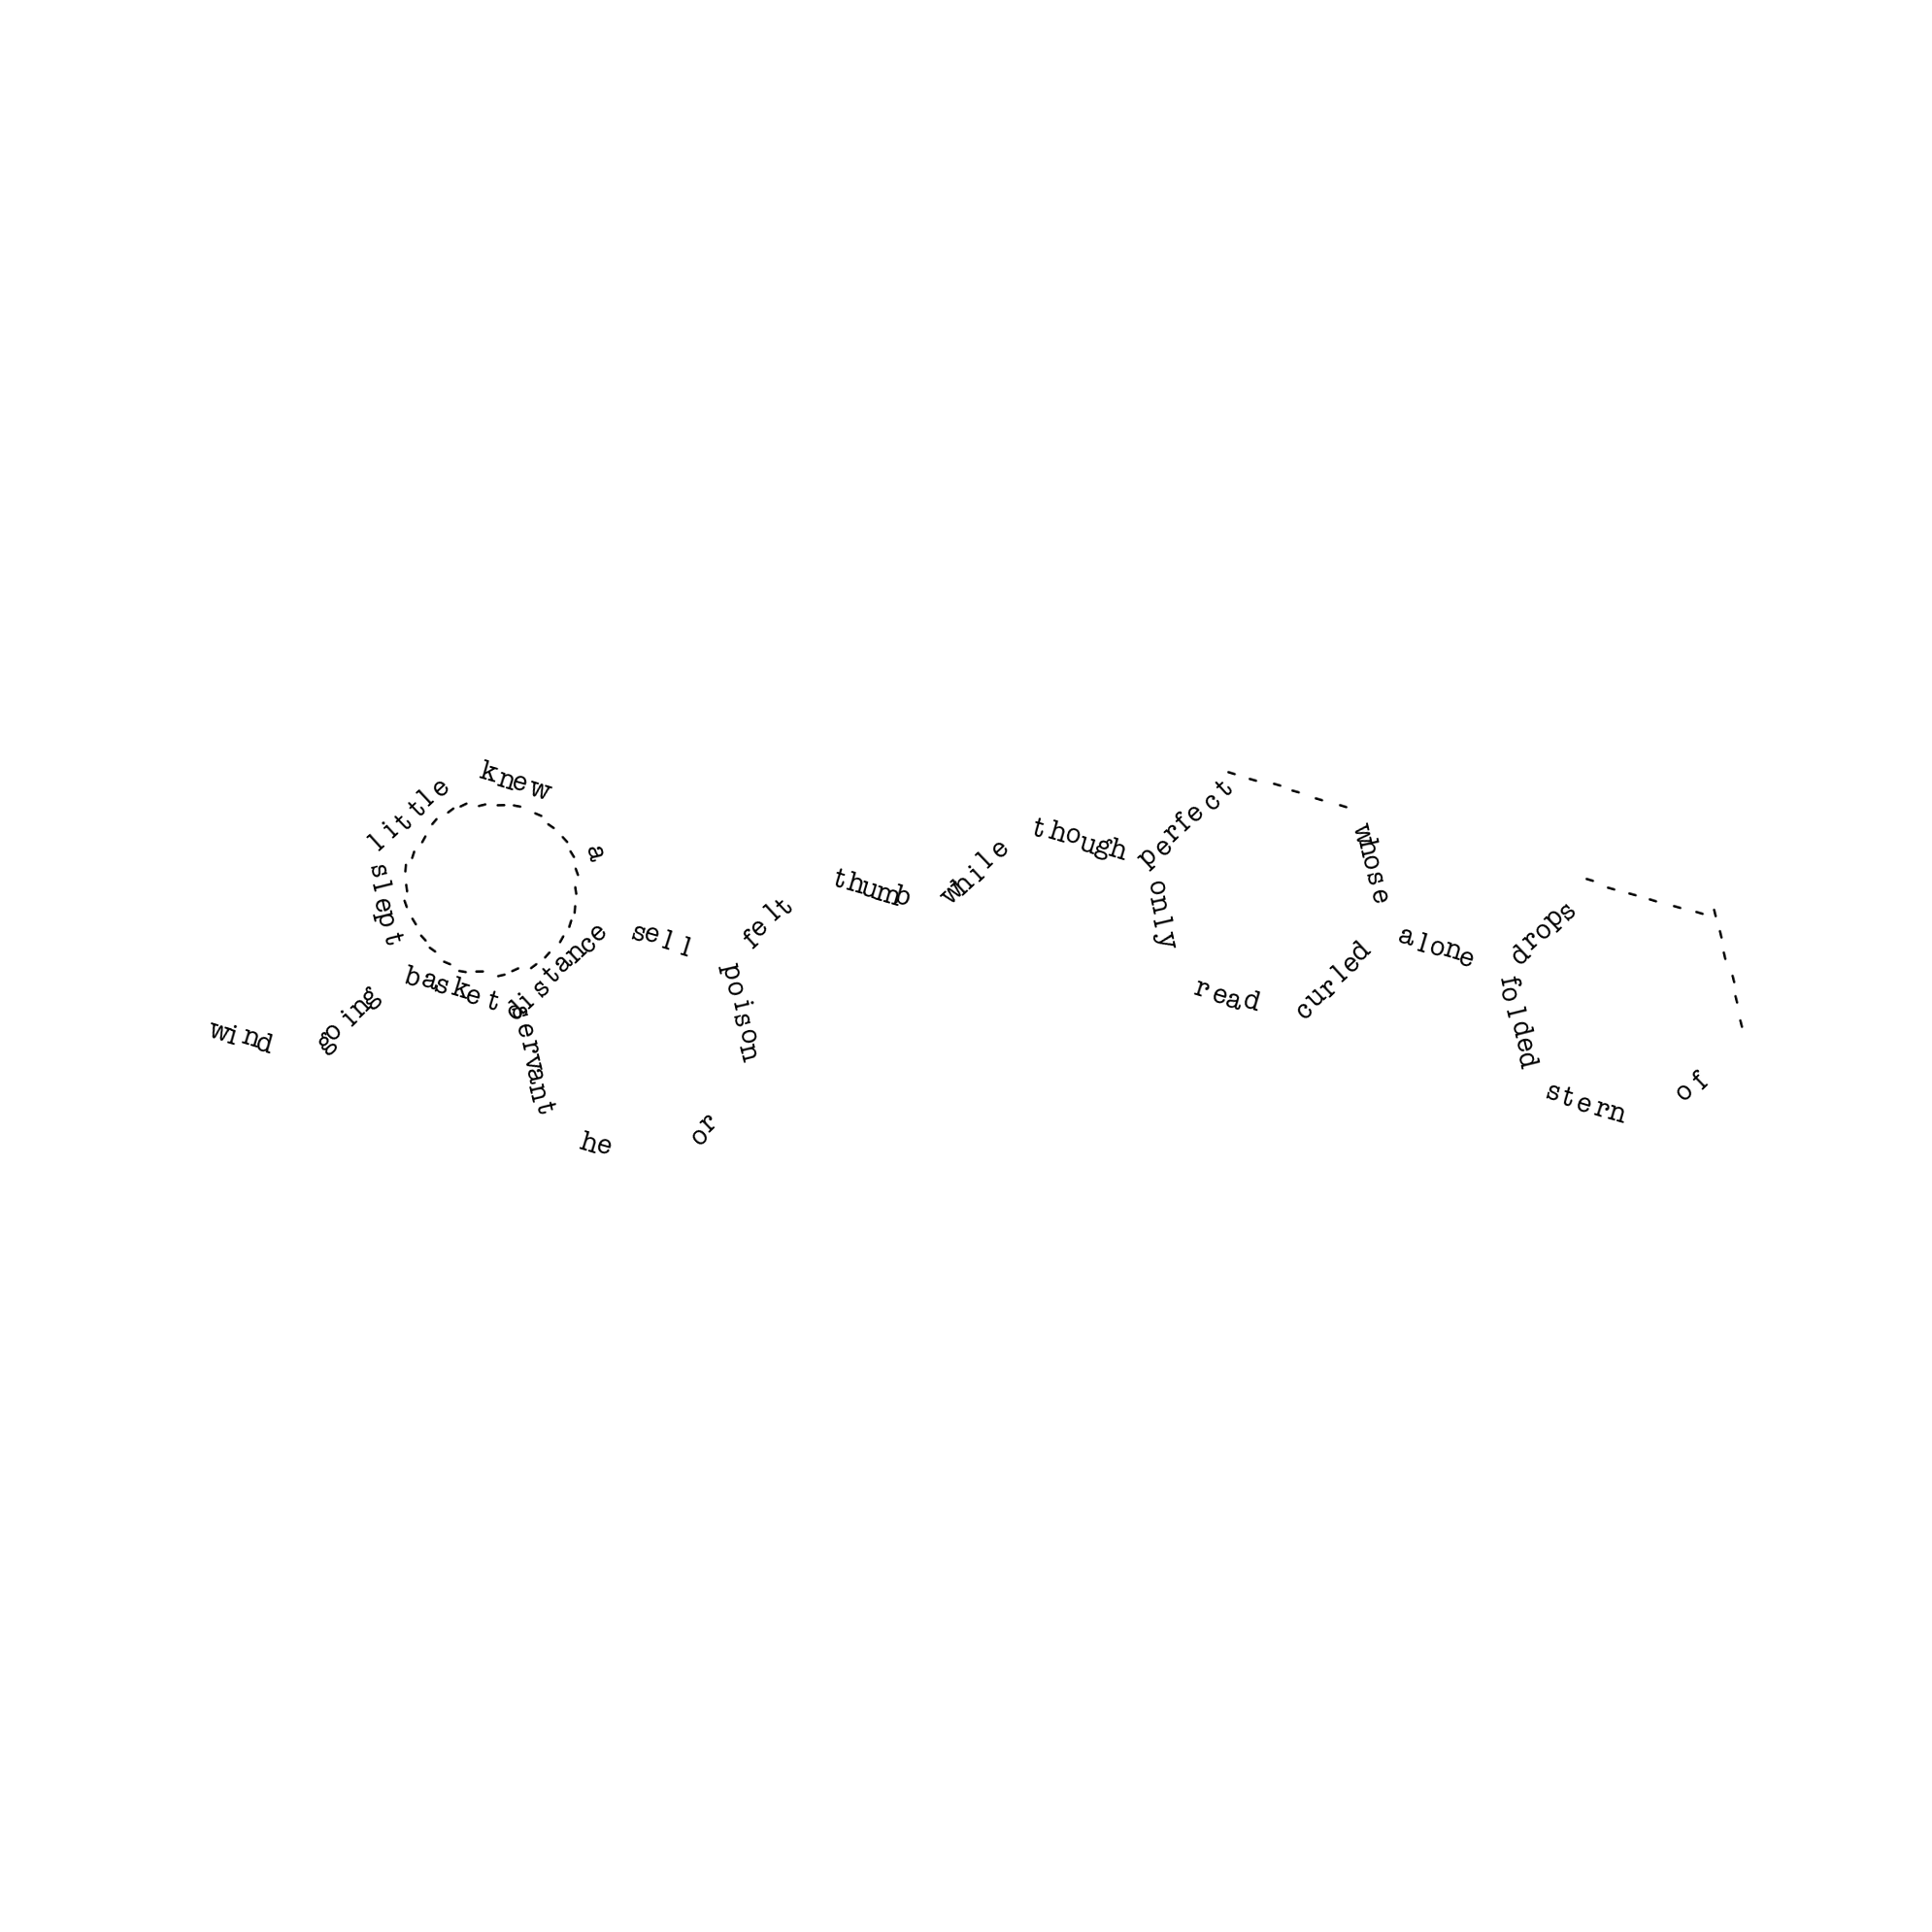

In [151]:
index = 53
# print(df.iloc[index]['smiles'])
# hybrid_word_bond_molecule(df.iloc[index]['smiles'], row_to_words(fps_array[index]))

# 1. With dashes (classic typewriter)
fig, mapping = typewriter_molecule_art_v2(
    smiles=df.iloc[index]['smiles'],
    words_to_embed=row_to_words(fps_array[index]),
    target_length=25,
    spacing_char='',
    font_size=25,
    vertical_jitter=0.03,
    letter_spacing_jitter=0.03,
    letter_spacing=0.01,
)
# plt.savefig('typewriter_dashes.png', dpi=300, bbox_inches='tight', facecolor='white')


[  1  33  41  80 117 119 128 222 227 243 259 294 318 375 420 476 482 540
 591 650 694 739 745 752 794 807 887 888 893 895 926]
[('and', 1), ('eyes', 33), ('there', 41), ('people', 80), ('thing', 117), ('some', 119), ('black', 128), ('walked', 222), ('moon', 227), ('than', 243), ('enemy', 259), ('nearly', 294), ('always', 318), ('doorway', 375), ('canoes', 420), ('bottle', 476), ('lighted', 482), ('clean', 540), ('destroyed', 591), ('arranged', 650), ('inches', 694), ('lying', 739), ('below', 745), ('hut', 752), ('bring', 794), ('pools', 807), ('valueless', 887), ('steps', 888), ('although', 893), ('trust', 895), ('nervous', 926)]
scale_factor  2.704521356852256  font_size  11.092535810076377
Mapped 16 words to 40 bonds
Bonds with words: [0, 1, 2, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 39]
Bonds without words: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38]


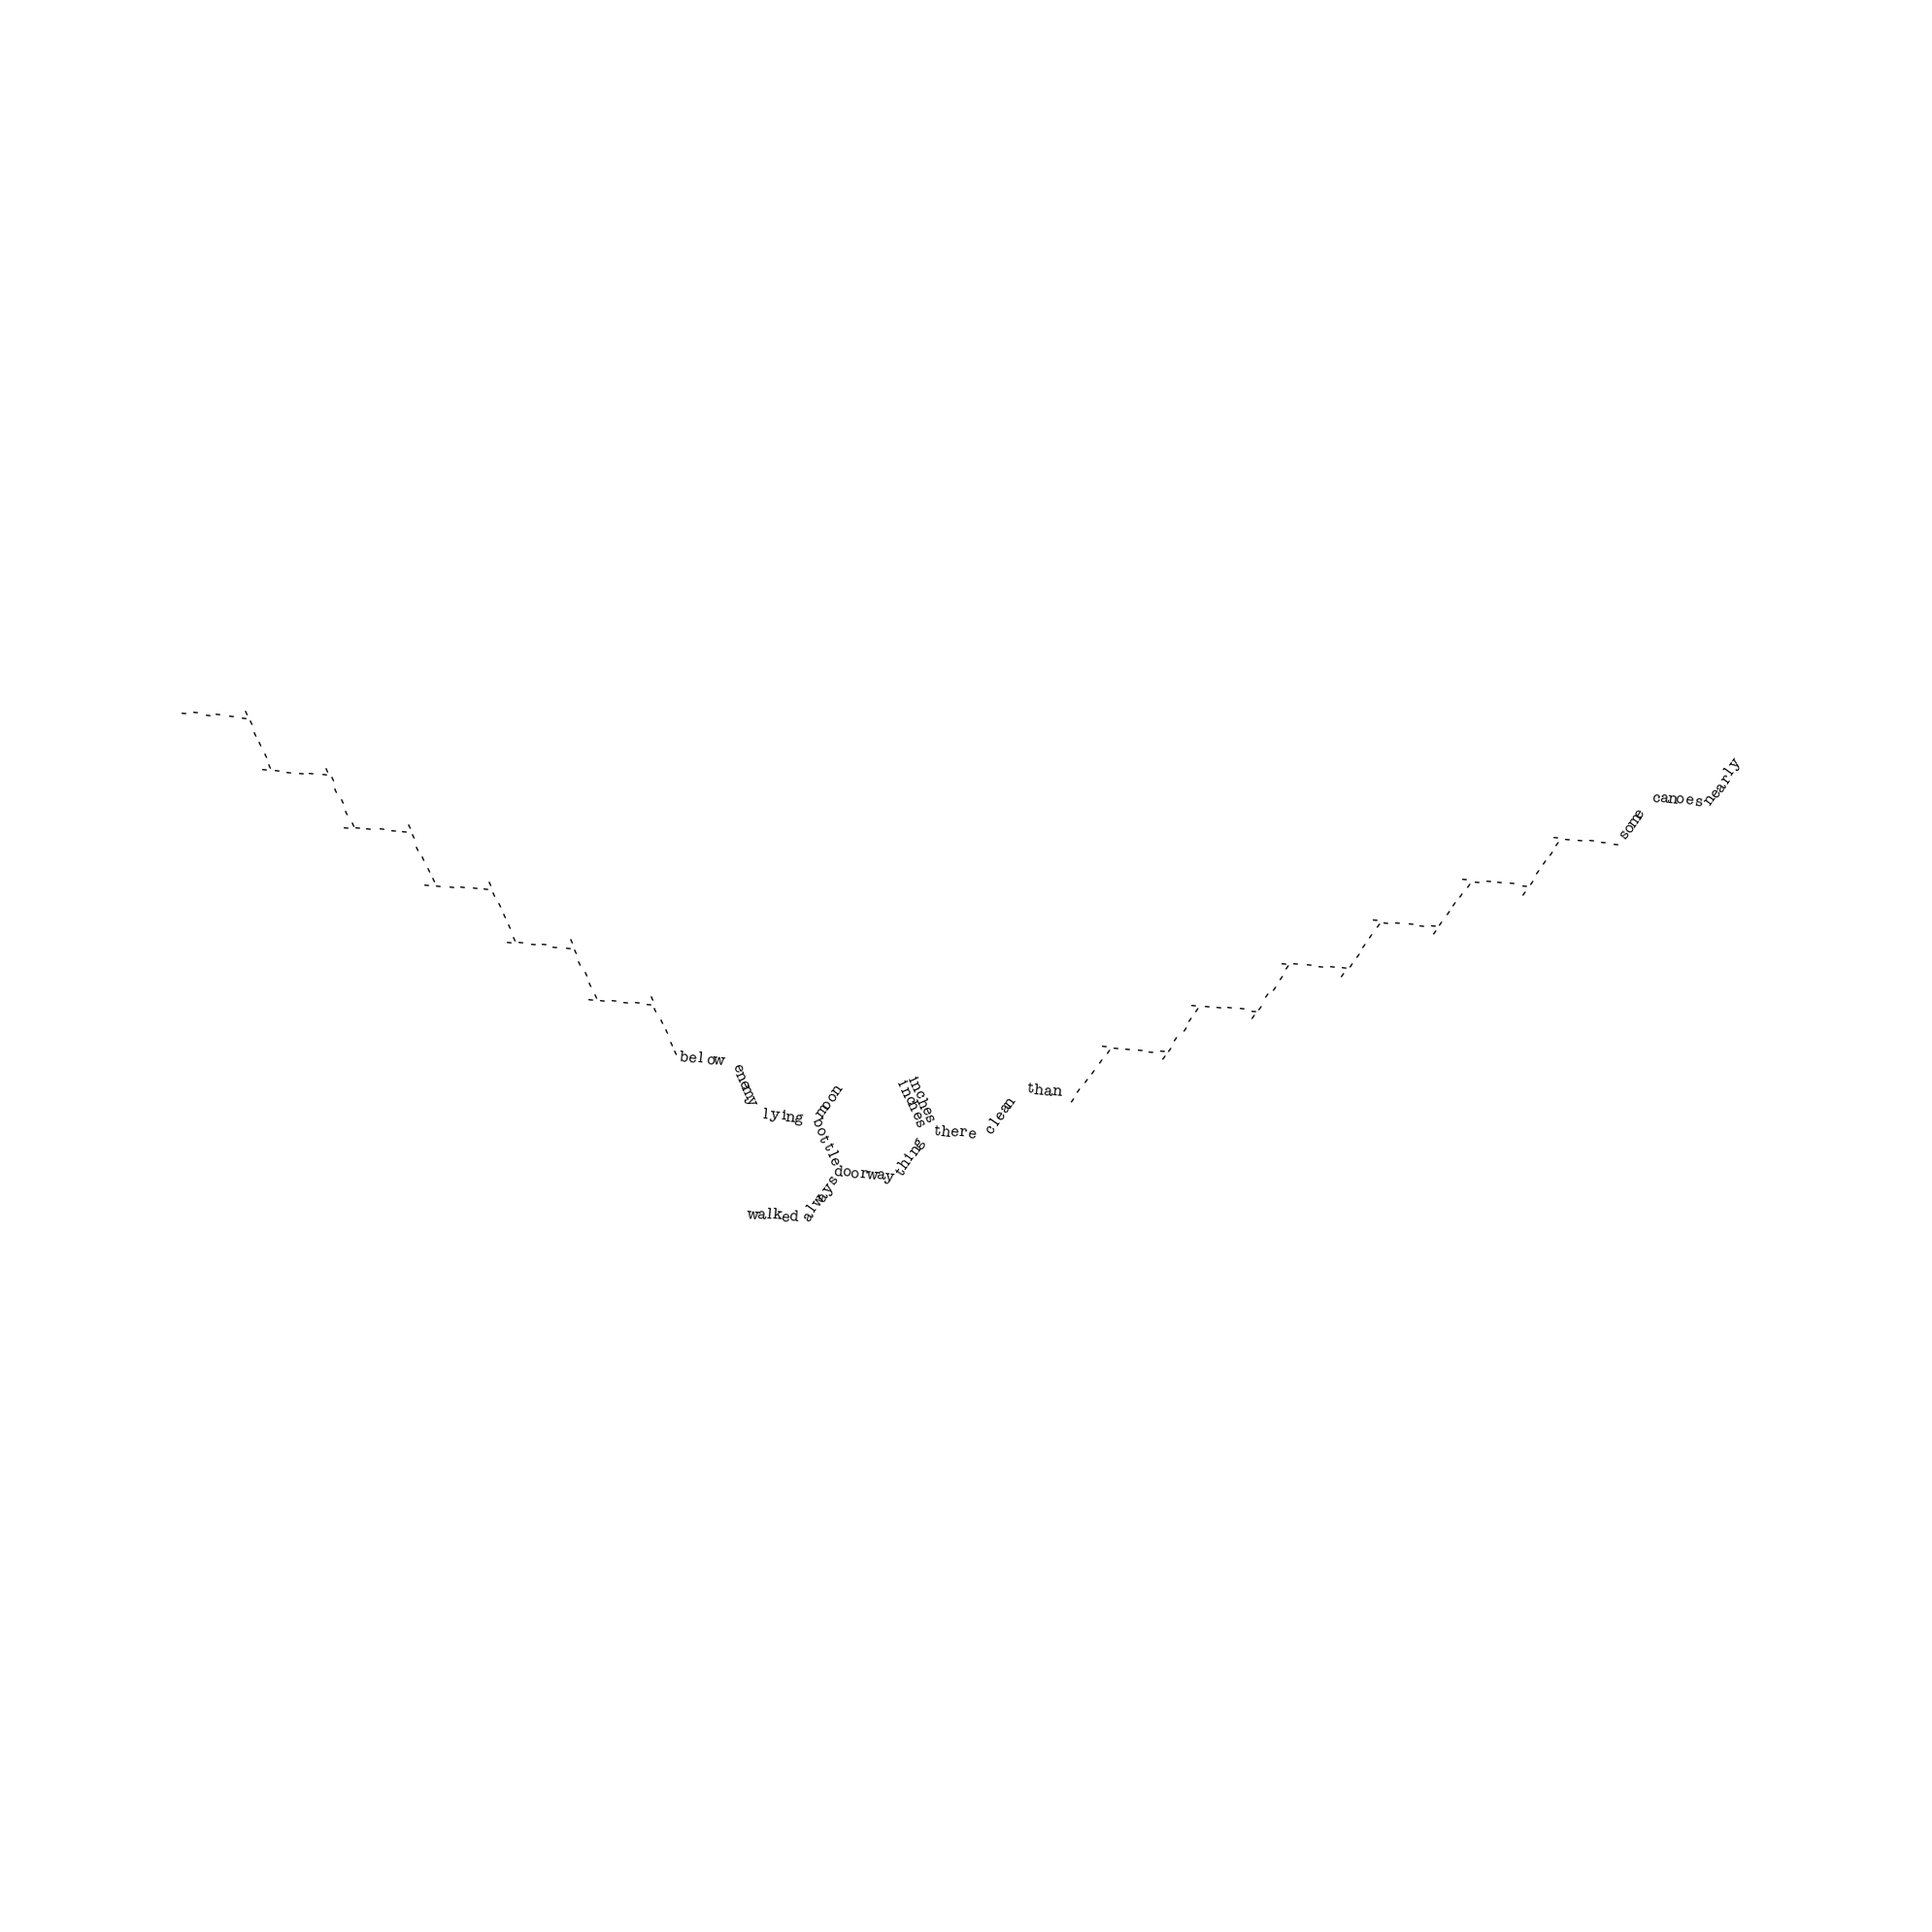

In [152]:
index = 54
# print(df.iloc[index]['smiles'])
# hybrid_word_bond_molecule(df.iloc[index]['smiles'], row_to_words(fps_array[index]))

# 1. With dashes (classic typewriter)
fig, mapping = typewriter_molecule_art_v2(
    smiles=df.iloc[index]['smiles'],
    words_to_embed=row_to_words(fps_array[index]),
    target_length=25,
    spacing_char='',
    font_size=30,
    vertical_jitter=0.03,
    letter_spacing_jitter=0.03,
    letter_spacing=0.02,
)
# plt.savefig('typewriter_dashes.png', dpi=300, bbox_inches='tight', facecolor='white')


[ 33  41  80 119 128 170 171 197 222 243 294 332 401 416 420 473 540 565
 591 597 646 650 667 694 723 731 775 794 807 849 887 893]
[('eyes', 33), ('there', 41), ('people', 80), ('some', 119), ('black', 128), ('thought', 170), ('soft', 171), ('lips', 197), ('walked', 222), ('than', 243), ('nearly', 294), ('money', 332), ('close', 401), ('animals', 416), ('canoes', 420), ('picked', 473), ('clean', 540), ('breaking', 565), ('destroyed', 591), ('animal', 597), ('late', 646), ('arranged', 650), ('ever', 667), ('inches', 694), ('thus', 723), ('soul', 731), ('whispered', 775), ('bring', 794), ('pools', 807), ('laughed', 849), ('valueless', 887), ('although', 893)]
scale_factor  1.2402164449614985  font_size  20.15777173538132
Mapped 17 words to 22 bonds
Bonds with words: [0, 1, 2, 3, 4, 5, 6, 7, 11, 14, 15, 16, 17, 18, 19, 20, 21]
Bonds without words: [8, 9, 10, 12, 13]


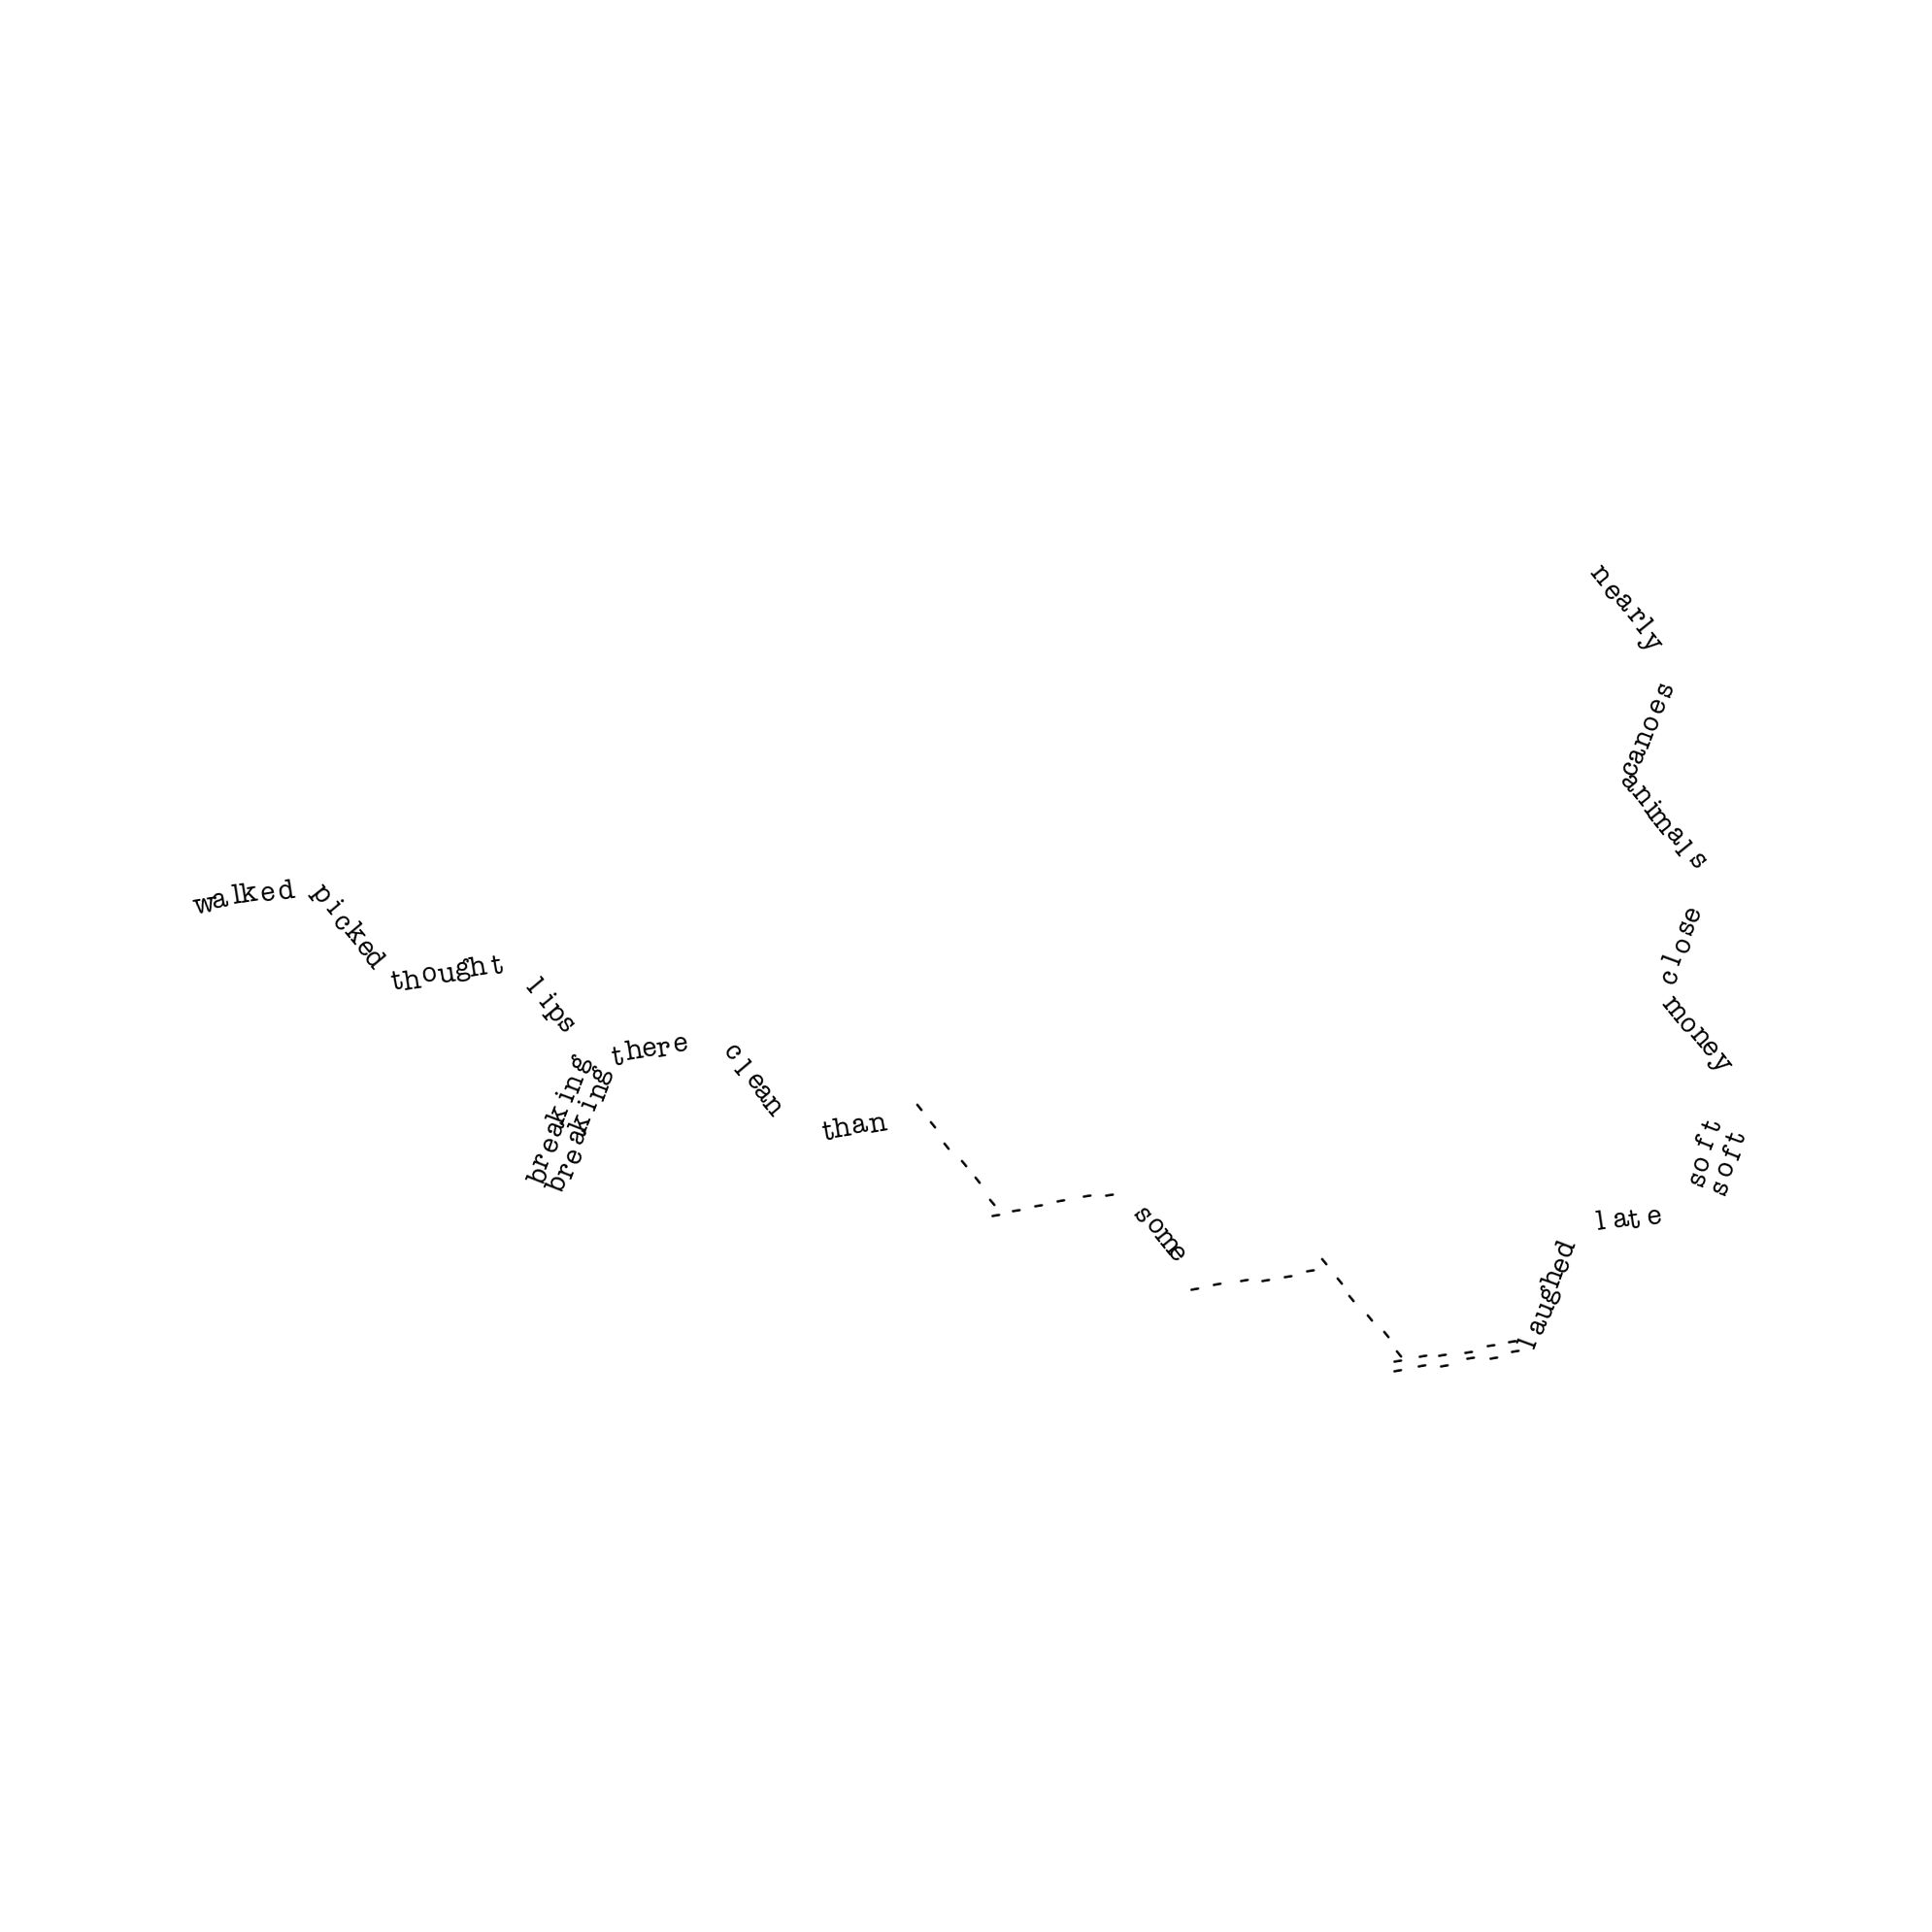

In [153]:
index = 55
# print(df.iloc[index]['smiles'])
# hybrid_word_bond_molecule(df.iloc[index]['smiles'], row_to_words(fps_array[index]))

# 1. With dashes (classic typewriter)
fig, mapping = typewriter_molecule_art_v2(
    smiles=df.iloc[index]['smiles'],
    words_to_embed=row_to_words(fps_array[index]),
    target_length=25,
    spacing_char='',
    font_size=25,
    vertical_jitter=0.03,
    letter_spacing_jitter=0.03,
    letter_spacing=0.01,
)
# plt.savefig('typewriter_dashes.png', dpi=300, bbox_inches='tight', facecolor='white')
